In [1]:
# ===== GWAS Pipeline v3 — Dependency Installation =====
import subprocess, sys, os
_DEVNULL = open(os.devnull, 'w')
_required = [
    'numpy', 'pandas', 'scipy', 'statsmodels', 'scikit-learn',
    'matplotlib', 'plotly', 'requests', 'kaleido',
    'psutil', 'natsort', 'seaborn',
]
for _pkg in _required:
    try:
        _import_name = 'sklearn' if _pkg == 'scikit-learn' else _pkg.replace('-', '_')
        __import__(_import_name)
    except ImportError:
        subprocess.check_call(
            [sys.executable, '-m', 'pip', 'install', _pkg],
            stdout=_DEVNULL, stderr=_DEVNULL)
        print(f"Installed {_pkg}")

_optional = ['pandas_plink', 'gseapy', 'mygene', 'ipywidgets', 'nbformat']
for _pkg in _optional:
    try:
        _import_name = 'sklearn' if _pkg == 'scikit-learn' else _pkg.replace('-', '_')
        __import__(_import_name)
    except ImportError:
        try:
            subprocess.check_call(
                [sys.executable, '-m', 'pip', 'install', _pkg],
                stdout=_DEVNULL, stderr=_DEVNULL)
            print(f"Installed optional: {_pkg}")
        except Exception:
            print(f"Optional package '{_pkg}' not available — skipping.")

# --- OS-Level Dependency Checker ---
from shutil import which
from pathlib import Path
_os_dep_alerts = []

# If a local './plink' exists, prepend its directory to PATH so which('plink') can resolve it.
_local_plink = Path.cwd() / 'plink'
if _local_plink.exists() and os.access(_local_plink, os.X_OK):
    os.environ['PATH'] = f"{_local_plink.parent}:{os.environ.get('PATH', '')}"
    print(f"Using local PLINK binary: {_local_plink}")

if which('plink') is None and which('plink_mac') is None and which('plink2') is None:
    _os_dep_alerts.append("WARNING: PLINK not found in PATH. Pre-processing for large CSV/binary files will fallback or fail.")

if which('java') is None:
    _os_dep_alerts.append("WARNING: Java not found in PATH. Beagle imputation cannot be utilized.")

if which('Rscript') is None:
    _os_dep_alerts.append("WARNING: R / Rscript not found in PATH. External models (mrMLM, FarmCPU, BLINK) will be gracefully skipped.")
else:
    # Check R libraries safely without installing
    def _check_r_lib(lib):
        return subprocess.run(['Rscript', '-e', f'if (!requireNamespace("{lib}", quietly=TRUE)) quit(status=1)'], stdout=_DEVNULL, stderr=_DEVNULL).returncode == 0

    _missing_r = []
    for _rlib in ["mrMLM", "BLINK", "FarmCPUpp", "FarmCPU"]:
        # Only strict require FarmCPUpp or FarmCPU, one is fine.
        if _rlib == "FarmCPU":
            if "FarmCPUpp" in _missing_r and not _check_r_lib("FarmCPU"):
                _missing_r.append("FarmCPU/FarmCPUpp")
                _missing_r.remove("FarmCPUpp")
            continue
        elif not _check_r_lib(_rlib):
            _missing_r.append(_rlib)

    if _missing_r:
        _os_dep_alerts.append(f"WARNING: The following R packages are missing: {', '.join(_missing_r)}.")
        _os_dep_alerts.append("         External models will be gracefully skipped. (Please see README.md for R installation instructions).")

_DEVNULL.close()
print("All Python dependencies ready.")

if _os_dep_alerts:
    print("\n--- SYSTEM DEPENDENCY ALERTS ---")
    for alert in _os_dep_alerts:
        print(alert)
    print("--------------------------------")
    print("Note: The pipeline's core Python models (GLM, LMM, LOCO) will still operate perfectly without these!\n")


Using local PLINK binary: /work/plink
All Python dependencies ready.


# CustomGWAS Pipeline v3: End-to-End Onboarding and Execution Guide

This notebook is the final integrated GWAS workflow for multi-format genotype input, quality control, multiple association models, and reporting.

## 0. Before You Run Anything

Run the dependency installation cell first, then confirm all system checks are clean.

Core Python models can run without all external tools, but external model and imputation paths require their matching executables.

## 1. External Dependencies Checklist

### Mandatory for full pipeline parity
1. PLINK 1.9 or compatible PLINK executable in PATH (`plink`, `plink_mac`, or `plink2`).
2. R and Rscript in PATH for mrMLM/FarmCPU/BLINK execution.
3. Java in PATH for Beagle imputation.

### Python packages
The dependency cell installs required and optional Python packages into the active notebook environment.

### Verify executable resolution
On macOS, common executable locations are:
- `/opt/homebrew/bin/Rscript`
- `/usr/local/bin/Rscript`
- `/opt/homebrew/bin/plink`

If your shell can find a tool but notebook cannot, restart the kernel after fixing PATH.

## 2. Required External Files in Workspace

Keep these files in the working directory unless absolute paths are used in configuration.

### Always required
- Genotype input:
  - CSV mode: one genotype CSV (`GENO_FORMAT='csv'`)
  - PLINK mode: `.bed/.bim/.fam` trio (`GENO_FORMAT='plink'` + prefix in `GENO_PATH`)
  - VCF mode: `.vcf` file (`GENO_FORMAT='vcf'`)
- Phenotype CSV referenced by `PHENO_PATH`

### Conditionally required
- Covariate CSV when `COVARIATE_PATH` is not `None`
- `run_blink.R` when external R models are enabled
- Beagle JAR referenced by `BEAGLE_JAR` when `RUN_BEAGLE_IMPUTATION=True`

### Compatibility checks
- Sample IDs must align across genotype, phenotype, and covariates.
- `TRAIT_NAME` must match a phenotype CSV column exactly.
- PLINK prefix must resolve to all three files.
- Beagle JAR must be compatible with installed Java runtime.

## 3. External Script and Runtime Contract

`run_blink.R` is a required integration boundary for BLINK/FarmCPU/mrMLM workflows. Do not remove or rename it unless caller code is updated.

## 4. Troubleshooting Fast Start

1. Dependency cell reports missing executable:
    - install tool, expose it in notebook PATH, restart kernel.
2. External models fail while Python models pass:
    - verify `Rscript`, R packages, and `run_blink.R` location.
3. Beagle fails:
    - verify Java and `BEAGLE_JAR` path/version.
4. Memory spikes:
    - lower chunk-size settings and use float32.

## 5. Pipeline Feature Map

| Area | What it covers |
|---|---|
| Input | CSV, PLINK, VCF loading + sample alignment |
| QC | Sample call-rate, heterozygosity, SNP call-rate/HWE/MAF |
| Structure correction | LD pruning, PCA, kinship-aware models |
| Association | Naive GLM, PCA-GLM, LMM, LOCO-LMM, Stepwise MLM, optional external models |
| Reporting | Logs, summary tables, and visualizations |


---
## 1. Configuration: Complete Parameter Reference

Set every parameter in the next code cell before running the pipeline.

### Input and output
| Parameter | Meaning | Guidance |
|---|---|---|
| `GENO_PATH` | Genotype file path or PLINK prefix | Must match `GENO_FORMAT` |
| `GENO_FORMAT` | Input mode (`csv`, `plink`, `vcf`) | Keep consistent with files on disk |
| `PHENO_PATH` | Phenotype CSV path | First column should be sample ID |
| `TRAIT_NAME` | Target phenotype column | Exact header match required |
| `OUTPUT_PREFIX` | Prefix for all output artifacts | Use run-specific naming |

### Covariates and study context
| Parameter | Meaning | Guidance |
|---|---|---|
| `COVARIATE_PATH` | Covariate CSV or `None` | Set `None` to disable |
| `COVARIATE_COLUMNS` | Selected covariate columns or all | `None` means all valid columns |
| `SPECIES` | Species keyword for annotations | Use supported value only |
| `TRAIT_TYPE` | `continuous` or `binary` | Must match phenotype encoding |

### CSV and parsing control
| Parameter | Meaning | Guidance |
|---|---|---|
| `LARGE_FILE_THRESHOLD_MB` | Size cutoff for large-file strategy | Lower on low RAM |
| `CSV_CHUNK_SIZE` | CSV chunk size for scalable loading | Lower reduces memory peak |
| `MIN_SNPS_PER_CHROMOSOME` | Consolidation threshold for sparse chromosomes | Raise to reduce tiny chromosome groups |

### Sample QC
| Parameter | Meaning | Guidance |
|---|---|---|
| `SAMPLE_CALLRATE_THRESHOLD` | Min non-missing fraction per sample | `0.80` removes >20% missing |
| `HET_RATE_FILTER` | Enable heterozygosity outlier filter | Keep `True` for first-pass QC |
| `HET_RATE_N_SD` | SD multiplier for heterozygosity outliers | `3.0` is conservative |

### SNP QC and imputation
| Parameter | Meaning | Guidance |
|---|---|---|
| `SNP_CALLRATE_THRESHOLD` | Min SNP call rate | `0.90` removes >10% missing |
| `RUN_HWE_FILTER` | Enable HWE filter | Commonly disabled for inbred panels |
| `HWE_P_THRESHOLD` | HWE cutoff | Smaller is stricter |
| `MAF_THRESHOLD` | MAF floor | Increase to remove rare variants |
| `IMPUTATION_METHOD` | Missing-genotype strategy (`mean`, `median`, `knn`) | `mean`/`median` are fastest |

### Phenotype QC
| Parameter | Meaning | Guidance |
|---|---|---|
| `DROP_MISSING_PHENOTYPES` | Remove samples missing a phenotype | `True` is strongly recommended for GWAS |
| `REMOVE_PHENOTYPE_OUTLIERS` | Enable trait outlier filtering | Keep enabled unless curated trait |
| `OUTLIER_METHOD` | Outlier rule (`iqr`, `zscore`) | `iqr` is robust to heavy tails |
| `OUTLIER_THRESHOLD` | Outlier stringency | Increase to retain more samples |
| `CHECK_PHENOTYPE_DISTRIBUTION` | Run distribution diagnostics | Keep enabled |
| `TRANSFORM_PHENOTYPE_IF_SKEWED` | Transform skewed traits | Keep enabled for robust modeling |

### LD pruning and PCA
| Parameter | Meaning | Guidance |
|---|---|---|
| `LD_PRUNE_BEFORE_PCA` | Prune SNPs before PCA | Usually `True` |
| `LD_PRUNE_WINDOW_SIZE` | Window width (SNP count) | Larger is more expensive |
| `LD_PRUNE_STEP_SIZE` | Sliding step size | Smaller is more exhaustive |
| `LD_PRUNE_R2_THRESHOLD` | LD threshold | Lower gives stronger pruning |
| `AUTO_SELECT_PCS` | Auto-select number of PCs | Disable for explicit control |
| `NUM_PCS` | Manual PC count | 5-20 is a common range |

### Beagle imputation
| Parameter | Meaning | Guidance |
|---|---|---|
| `RUN_BEAGLE_IMPUTATION` | Enable Beagle path | Requires Java and JAR |
| `BEAGLE_JAR` | Beagle JAR path | Ensure version compatibility |
| `BEAGLE_JAVA_MEM` | Java heap passed to Beagle | Increase for large datasets |
| `BEAGLE_NE` | Effective population size | Use study-appropriate value |

### Models and significance
| Parameter | Meaning | Guidance |
|---|---|---|
| `RUN_NAIVE_GLM` | Baseline linear model | Fast sanity baseline |
| `RUN_PCA_GLM` | PCA-corrected linear model | Strong default comparator |
| `RUN_LMM` | Exact mixed model | Robust to relatedness |
| `RUN_LOCO_LMM` | Chromosome-excluded mixed model | Reduces proximal contamination |
| `RUN_MLM_STEPWISE` | Stepwise mixed model | Captures secondary effects |
| `SIGNIFICANCE_ALPHA` | Significance alpha | Typically `0.05` |

### Memory and reproducibility
| Parameter | Meaning | Guidance |
|---|---|---|
| `MAX_MEMORY_GB` | Soft memory budget | Match available RAM |
| `FORCE_FLOAT32` | Use float32 memory mode | Keep `True` for larger matrices |
| `RANDOM_SEED` | Random seed | Keep fixed for reproducibility |
| `LOG_TO_FILE` | Write run log | Keep enabled for audits |
| `LOG_FILE_PATH` | Log output path | Keep under output prefix |
| `BENCHMARK` | Runtime/memory benchmarking toggle | Keep enabled during tuning |


In [ ]:
# ==============================================================================
# 1. CONFIGURATION -- edit this cell, then Run All
# ==============================================================================

from datetime import datetime

# --- Input / Output ---
GENO_PATH  = 'BAAP_clean'        # CSV path, PLINK prefix, or VCF path
GENO_FORMAT = 'plink'                      # 'csv', 'plink', or 'vcf'
PHENO_PATH  = 'BAAP_Pheno_Mn1_AWD_Grain.csv'
TRAIT_NAME  = 'Mn1_AWD_Grain'
OUTPUT_PREFIX = 'BAAP_GWAS_v3_output'
RUNS_ROOT = 'runs'                         # root directory where each run gets its own folder

# Auto-timestamp run labels like GWAS_v3_output_20260312_105555
AUTO_TIMESTAMP_RUN_LABEL = True
RUN_LABEL_TIMESTAMP_FORMAT = '%Y%m%d_%H%M%S'

# Normalize output routing so every run is isolated under runs/<RUN_LABEL>/
_user_output_prefix = str(OUTPUT_PREFIX).strip()
if os.path.dirname(_user_output_prefix):
    OUTPUT_DIR = os.path.dirname(_user_output_prefix)
    RUN_LABEL = os.path.basename(_user_output_prefix)
else:
    RUN_LABEL = _user_output_prefix

if AUTO_TIMESTAMP_RUN_LABEL:
    _run_ts = datetime.now().strftime(RUN_LABEL_TIMESTAMP_FORMAT)
    RUN_LABEL = f"{RUN_LABEL}_{_run_ts}"

OUTPUT_DIR = os.path.join(RUNS_ROOT, RUN_LABEL) if not os.path.dirname(_user_output_prefix) else os.path.join(OUTPUT_DIR, RUN_LABEL)
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_PREFIX = os.path.join(OUTPUT_DIR, RUN_LABEL)

# Toggle inline interactive rendering; HTML files are always saved regardless.
SHOW_INTERACTIVE_IN_NOTEBOOK = False

# --- Covariate support (set to None to skip) ---
COVARIATE_PATH    = None            # CSV with first col = Sample ID
COVARIATE_COLUMNS = None            # list of column names, or None = use all

# --- Reproducibility ---
RANDOM_SEED   = 42
LOG_TO_FILE   = True
LOG_FILE_PATH = f'{OUTPUT_PREFIX}_pipeline.log'

# --- Biological context ---
SPECIES    = 'rice'          # 'human', 'rice', 'mouse', 'arabidopsis', 'maize'
TRAIT_TYPE = 'continuous'    # 'continuous' or 'binary'

# --- CSV handling ---
LARGE_FILE_THRESHOLD_MB = 50      # when CSV exceeds this size, pipeline may switch to more scalable path
CSV_CHUNK_SIZE          = 500_000 # row chunk size for large CSV handling
MIN_SNPS_PER_CHROMOSOME = 2       # sparse chromosomes below this count are consolidated

# --- Sample-level QC ---
SAMPLE_CALLRATE_THRESHOLD = 0.90   # remove samples missing >20 % genotypes. default 0.80
HET_RATE_FILTER           = False  # filter by heterozygosity rate
HET_RATE_N_SD             = 3.0    # +/- N standard deviations from mean

# --- SNP-level QC ---
SNP_CALLRATE_THRESHOLD = 0.90       # remove SNPs with >10 % missing. default 0.90
RUN_HWE_FILTER         = False      # set to True to filter SNPs deviating from Hardy-Weinberg Equilibrium
HWE_P_THRESHOLD        = 1e-6       # HWE p-value threshold for filtering (only if RUN_HWE_FILTER is True)
MAF_THRESHOLD          = 0.05       # remove SNPs with minor allele frequency <5%
IMPUTATION_METHOD      = 'mean'     # 'mean', 'median', or 'knn'

# --- Phenotype QC ---
DROP_MISSING_PHENOTYPES     = True      # highly recommended to avoid false positives from median imputation
REMOVE_PHENOTYPE_OUTLIERS   = False
OUTLIER_METHOD              = 'iqr'     # 'iqr' or 'zscore'
OUTLIER_THRESHOLD           = 1.5       # IQR multiplier or z-score threshold depending on OUTLIER_METHOD
CHECK_PHENOTYPE_DISTRIBUTION = True     # evaluate phenotype distribution prior to modeling
TRANSFORM_PHENOTYPE_IF_SKEWED = False   # apply transformation to improve model assumptions if needed

# --- LD pruning ---
LD_PRUNE_BEFORE_PCA   = True    # recommended to reduce dimensionality and improve PCA performance
LD_PRUNE_WINDOW_SIZE  = 50      # SNPs
LD_PRUNE_STEP_SIZE    = 10      # SNPs
LD_PRUNE_R2_THRESHOLD = 0.5     # remove one SNP of any pair with r^2 > threshold within the window

# --- PCA ---
AUTO_SELECT_PCS = False        # if True, number of PCs is determined by parallel analysis; if False, uses NUM_PCS
NUM_PCS         = 5            # used when AUTO_SELECT_PCS is False or as fallback

# --- Beagle imputation ---
RUN_BEAGLE_IMPUTATION = False                           # set to True to perform imputation with Beagle (requires Java and Beagle JAR)
BEAGLE_JAR            = 'beagle.27Feb25.75f.jar'        # path to Beagle JAR file; if not found, imputation will be skipped
BEAGLE_JAVA_MEM       = '100g'                          # Java memory allocation for Beagle (e.g., '4g' for 4 GB)
BEAGLE_NE             = 100000                          # Effective population size for Beagle imputation (adjust based on species; e.g., 10000 for human, 5000 for rice)

# --- Models ---
RUN_NAIVE_GLM    = True           # Fastest, basic regression without structure correction
RUN_PCA_GLM      = True           # Corrects for broad population stratification using PCA
RUN_EMMAX        = True           # Standard mixed model (P3D approximation) used widely in genetics
RUN_LMM          = True           # Exact Linear Mixed Model accounting for kinship/relatedness
RUN_LOCO_LMM     = False          # Leave-One-Chromosome-Out LMM (avoids proximal contamination)
RUN_MLM_STEPWISE = False          # Stepwise testing including top signals as co-factors
RUN_BLINK        = False          # Fast multi-locus model replacing FarmCPU's bins with LD
RUN_FARMCPU      = False          # Iterative fixed/random effect model controlling false positives
RUN_MRMLM        = False          # Multi-Locus Random-SNP-Effect Mixed model
R_GWAS_CHUNK_SIZE = 2000          # chunk size for external R-based GWAS fallback scans
R_EXECUTABLE     = 'Rscript'      # command used to run external R models
SIGNIFICANCE_ALPHA = 0.10         #Default 0.05

# --- Clumping (LD-based) ---
CLUMP_R2_THRESHOLD = 0.1
CLUMP_WINDOW_KB    = 250            #Default 500
CLUMP_P_THRESHOLD  = 1e-4           #Default 1e-5
CLUMP_FALLBACK_WINDOW_KB = 250
CLUMP_FALLBACK_P_THRESHOLD = 1e-4   #Default 1e-5

# --- COJO / regional plots / catalog ---
RUN_COJO            = False        # set to True to perform GCTA-COJO conditional analysis on lead SNPs (requires GCTA installed and in PATH)
COJO_P_THRESHOLD    = 1e-5         # p-value threshold for selecting lead SNPs to condition on in COJO (set to None to use same as CLUMP_P_THRESHOLD)
COJO_MAX_SECONDARY  = 5            # maximum number of secondary signals to report per locus in COJO results
RUN_LOCUS_ZOOM      = True         # set to True to generate locus zoom plots for top loci (requires plotly and kaleido)
LOCUS_ZOOM_N_LOCI   = 3            # number of top loci to generate locus zoom plots for
LOCUS_ZOOM_WINDOW_KB = 500         # window size in kb for locus zoom plots around lead SNPs
RUN_GWAS_CATALOG    = False        # Use True only for human studies when you want novelty-vs-known comparison against published GWAS.
GWAS_CATALOG_WINDOW_BP = 50000     # window size in base pairs for querying GWAS Catalog around lead SNPs

# --- Polygenic Risk Score (PRS) ---
RUN_PRS           = False
PRS_P_THRESHOLDS  = [1e-5, 1e-4, 1e-3, 0.01, 0.05, 0.1, 0.5, 1.0]
PRS_BATCH_SIZE    = 2048
PRS_EVAL_MODE     = 'holdout'       # 'holdout' for train/test split evaluation, 'crossval' for k-fold cross-validation (not implemented yet)
PRS_HOLDOUT_FRACTION = 0.20         # fraction of samples to hold out for testing when PRS_EVAL_MODE is 'holdout'
PRS_HOLDOUT_SEED  = RANDOM_SEED     # random seed for reproducible train/test split in PRS evaluation
PRS_WEIGHT_MODEL  = 'pca'           # method for deriving SNP weights in PRS: 'pca' for PCA-based weighting, 'beta' for using effect sizes from the main GWAS, 'lasso' for Lasso regression (not implemented yet)

# --- Annotation / optional filters ---
SUGGESTIVE_P_THRESHOLD = 1e-5
ENSEMBL_ANNOT_DIST_KB = 10
RUN_IBD_FILTER = False
IBD_THRESHOLD  = 0.185
RELEASE_INTERMEDIATE_OBJECTS = False

# --- PDF report size controls (report only; does not affect saved HTML quality) ---
REPORT_PDF_DPI = 72
REPORT_PDF_COMPRESSION = 9
REPORT_MAX_POINTS = 120000 # maximum number of points to plot in scatter plots before rasterizing (set to None for no limit; rasterizing can improve performance but may reduce visual quality at low thresholds)
REPORT_RASTERIZE_SCATTER = True

# --- Memory management ---
MAX_MEMORY_GB  = 200.0 # maximum memory to use for in-memory operations; if exceeded, pipeline will switch to more scalable methods or skip certain steps
FORCE_FLOAT32  = False # use float32 instead of float64 for genotype matrices to reduce memory usage (may slightly reduce precision but usually not an issue for GWAS)
LOW_RAM_MODE   = False # if True, pipeline will automatically switch to more memory-efficient methods or skip certain steps when memory usage approaches MAX_MEMORY_GB (e.g., using on-disk formats, skipping LD pruning, etc.)

# --- Benchmarking ---
BENCHMARK = True   # enables runtime and memory benchmarking outputs

---
## 2 · Imports & Helpers


In [3]:
import time, re, gc, sys, os, csv, subprocess, platform, logging, hashlib, tracemalloc, shutil
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.decomposition import PCA
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy import stats
from scipy.optimize import minimize_scalar
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display, HTML
except ImportError:
    display = None
    HTML = None

try:
    from natsort import natsorted, ns
except ImportError:
    natsorted = sorted; ns = None

try:
    import psutil
except ImportError:
    psutil = None

import interactive_plots
import gwas_analytics

# ── Random seed ──────────────────────────────────────────────────────────
np.random.seed(RANDOM_SEED)

# ── Logging ──────────────────────────────────────────────────────────────
_file_logger = None
if LOG_TO_FILE:
    _file_logger = logging.getLogger('gwas_pipeline')
    _file_logger.setLevel(logging.DEBUG)
    _fh = logging.FileHandler(LOG_FILE_PATH, mode='w')
    _fh.setFormatter(logging.Formatter('%(asctime)s [%(levelname)s] %(message)s'))
    _file_logger.addHandler(_fh)

def log_message(message, level="INFO"):
    print(f"[{time.strftime('%H:%M:%S')}] [{level}] {message}")
    if _file_logger:
        _file_logger.log(getattr(logging, level, logging.INFO), message)

def format_bytes(size):
    for unit in ['B','KB','MB','GB','TB']:
        if size < 1024:
            return f"{size:.2f} {unit}"
        size /= 1024

def announce_interactive_plot(html_path, label="plot"):
    abs_path = os.path.abspath(html_path)
    uri = Path(abs_path).as_uri()
    log_message(f"Interactive {label} saved -> {abs_path}")
    print(f"Open interactive {label}: {uri}")
    if display is not None and HTML is not None:
        try:
            rel_path = os.path.relpath(abs_path)
            display(HTML(f'<a href="{rel_path}" target="_blank">Open interactive {label}</a>'))
        except Exception as e:
            log_message(f"Could not create clickable link for {label}: {e}", "WARNING")

def maybe_show_plotly_figure(fig, label="plot"):
    """Show a Plotly figure only when explicitly enabled in notebook output."""
    if fig is None:
        return
    if not bool(globals().get('SHOW_INTERACTIVE_IN_NOTEBOOK', False)):
        return
    try:
        fig.show()
    except Exception as e:
        log_message(f"Could not display {label}: {e}", "WARNING")

def save_interactive_plot(fig, html_path, label="plot"):
    """Save interactive Plotly HTML and optionally render inline."""
    if fig is None:
        return None
    fig.write_html(html_path)
    announce_interactive_plot(html_path, label=label)
    maybe_show_plotly_figure(fig, label=label)
    return html_path

def compress_pvalues_for_qq(p_values, max_points=200000):
    p = np.asarray(p_values)
    p = p[np.isfinite(p)]
    if p.size <= max_points:
        return p.astype(np.float32, copy=False)
    rng = np.random.default_rng(int(globals().get('RANDOM_SEED', 42)))
    idx = rng.choice(p.size, size=max_points, replace=False)
    return p[idx].astype(np.float32, copy=False)

def compact_numeric_dataframe(df, float_dtype=np.float32):
    if df is None or not isinstance(df, pd.DataFrame):
        return df
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in num_cols:
        s = df[col]
        if pd.api.types.is_float_dtype(s):
            df[col] = s.astype(float_dtype, copy=False)
        elif pd.api.types.is_integer_dtype(s):
            df[col] = pd.to_numeric(s, downcast='integer')
    return df

# ── Memory management ────────────────────────────────────────────────────
def check_memory(label=""):
    if psutil is None:
        return
    proc = psutil.Process(os.getpid())
    rss_gb = proc.memory_info().rss / 1024**3
    if rss_gb > MAX_MEMORY_GB * 0.85:
        log_message(f"[MEM {label}] RSS={rss_gb:.2f} GB — approaching limit, running gc.collect()", "WARNING")
        gc.collect()
    else:
        log_message(f"[MEM {label}] RSS={rss_gb:.2f} GB")

def get_float_dtype():
    return np.float32 if FORCE_FLOAT32 else np.float64

# ── Timer ────────────────────────────────────────────────────────────────
start_time = time.time()
if BENCHMARK:
    tracemalloc.start()

# ── Summary ──────────────────────────────────────────────────────────────
log_message("="*60)
log_message("GWAS Pipeline v3 — session started")
log_message(f"  Genotype : {GENO_PATH} ({GENO_FORMAT})")
log_message(f"  Phenotype: {PHENO_PATH}  trait={TRAIT_NAME}")
log_message(f"  Covariates: {COVARIATE_PATH}")
log_message(f"  Species  : {SPECIES}   trait_type={TRAIT_TYPE}")
log_message(f"  Float    : {'float32' if FORCE_FLOAT32 else 'float64'}   max_mem={MAX_MEMORY_GB} GB   seed={RANDOM_SEED}")
log_message(f"  Output dir: {os.path.abspath(OUTPUT_DIR)}")
log_message(f"  Inline interactive plots: {bool(globals().get('SHOW_INTERACTIVE_IN_NOTEBOOK', False))}")
log_message("="*60)


[16:26:42] [INFO] ============================================================
[16:26:42] [INFO] GWAS Pipeline v3 — session started
[16:26:42] [INFO]   Genotype : BAAP_clean (plink)
[16:26:42] [INFO]   Phenotype: BAAP_Pheno_Mn1_AWD_Grain.csv  trait=Mn1_AWD_Grain
[16:26:42] [INFO]   Covariates: None
[16:26:42] [INFO]   Species  : rice   trait_type=continuous
[16:26:42] [INFO]   Float    : float64   max_mem=200.0 GB   seed=42
[16:26:42] [INFO]   Output dir: /work/runs/BAAP_GWAS_v3_output_20260522_162641
[16:26:42] [INFO]   Inline interactive plots: False
[16:26:42] [INFO] ============================================================


---
## 3 · Pipeline Core Functions


In [4]:
# ==============================================================================
# DATA LOADING (CSV / PLINK / VCF) + COVARIATE LOADING
# ==============================================================================

def load_genotypes(file_path, file_format):
    '''Load genotype data. Returns (geno_df, snp_metadata_df).'''
    fdtype = get_float_dtype()
    log_message(f"Loading genotypes from '{file_path}' (format={file_format})…")

    if file_format.lower() == 'csv':
        file_size = Path(file_path).stat().st_size / 1024**2
        log_message(f"CSV size: {file_size:.1f} MB")
        header_df = pd.read_csv(file_path, nrows=0)
        n_cols = len(header_df.columns)
        if n_cols > 10_000 or file_size > 500:
            return load_genotypes_selective_columns(file_path, max_snps_per_chunk=20_000)
        dtypes = {col: 'Int8' for col in header_df.columns[1:]}
        geno_df = pd.read_csv(file_path, dtype=dtypes, index_col=0,
                              engine='c', na_values=['NA','nan','','.', '-9'])
        geno_df.index = geno_df.index.astype(str)
        snp_meta = pd.DataFrame({'SNP_ID': geno_df.columns.astype(str)})
        gc.collect(); check_memory("csv load")
        return geno_df, snp_meta

    elif file_format.lower() == 'plink':
        from pandas_plink import read_plink1_bin
        bed = f"{file_path}.bed"
        bim = f"{file_path}.bim"
        fam = f"{file_path}.fam"
        for f in [bed, bim, fam]:
            if not Path(f).exists():
                raise FileNotFoundError(f"Missing: {f}")
        G_dask = read_plink1_bin(bed, verbose=False)
        vals = G_dask.values.compute() if hasattr(G_dask.values, 'compute') else G_dask.values
        sample_ids = G_dask.iid.values.astype(str) if hasattr(G_dask, 'iid') else pd.read_csv(fam, sep=r'\s+', header=None)[1].astype(str).values
        snp_ids = G_dask.snp.values.astype(str) if hasattr(G_dask, 'snp') else pd.read_csv(bim, sep=r'\s+', header=None)[1].astype(str).values
        if hasattr(G_dask, 'chrom') and hasattr(G_dask, 'pos'):
            chroms = G_dask.chrom.values.astype(str)
            positions = G_dask.pos.values
        else:
            bim_df = pd.read_csv(bim, sep=r'\s+', header=None, names=['chrom','SNP_ID','cm','pos','a1','a2'])
            chroms = bim_df['chrom'].astype(str).values
            positions = bim_df['pos'].values
        geno_df = pd.DataFrame(vals.astype(fdtype), index=sample_ids, columns=snp_ids)
        snp_meta = pd.DataFrame({'SNP_ID': snp_ids, 'chrom': chroms, 'pos': positions})
        del vals; gc.collect(); check_memory("plink load")
        log_message(f"Loaded {geno_df.shape[0]} samples × {geno_df.shape[1]} SNPs from PLINK")
        return geno_df, snp_meta

    elif file_format.lower() == 'vcf':
        return load_genotypes_vcf(file_path)

    else:
        raise ValueError(f"Unsupported GENO_FORMAT: {file_format}")


def load_genotypes_vcf(vcf_path):
    '''Pure-Python VCF parser -> (geno_df, snp_metadata).'''
    fdtype = get_float_dtype()
    log_message(f"Parsing VCF: {vcf_path}")
    sample_ids = None
    snp_rows, meta_rows = [], []
    with open(vcf_path) as fh:
        for line in fh:
            if line.startswith('##'):
                continue
            if line.startswith('#CHROM'):
                parts = line.strip().split('\t')
                sample_ids = parts[9:]
                continue
            cols = line.strip().split('\t')
            chrom, pos, snp_id = cols[0], int(cols[1]), cols[2]
            if snp_id == '.':
                snp_id = f"{chrom}:{pos}"
            fmt_fields = cols[8].split(':')
            gt_idx = fmt_fields.index('GT') if 'GT' in fmt_fields else 0
            dosages = []
            for samp in cols[9:]:
                gt_str = samp.split(':')[gt_idx]
                alleles = re.split(r'[/|]', gt_str)
                if '.' in alleles:
                    dosages.append(np.nan)
                else:
                    dosages.append(sum(int(a) for a in alleles))
            snp_rows.append(dosages)
            meta_rows.append({'SNP_ID': snp_id, 'chrom': str(chrom), 'pos': pos})
    G = np.array(snp_rows, dtype=fdtype).T          # (samples × snps)
    geno_df = pd.DataFrame(G, index=[str(s) for s in sample_ids],
                           columns=[m['SNP_ID'] for m in meta_rows])
    snp_meta = pd.DataFrame(meta_rows)
    log_message(f"VCF loaded: {geno_df.shape[0]} samples × {geno_df.shape[1]} SNPs")
    gc.collect(); check_memory("vcf load")
    return geno_df, snp_meta


def load_phenotypes(file_path, trait_name):
    '''Load phenotype CSV -> pd.Series with string index.'''
    log_message(f"Loading phenotypes: {file_path} -> {trait_name}")
    df = pd.read_csv(file_path).set_index(pd.read_csv(file_path).columns[0])
    df.index = df.index.astype(str)
    if trait_name not in df.columns:
        raise KeyError(f"Trait '{trait_name}' not in phenotype file.")
    y = pd.to_numeric(df[trait_name], errors='coerce').rename('phenotype')
    log_message(f"  {y.count()} non-missing records")
    return y


def load_covariates(cov_path, cov_columns=None):
    '''Load external covariates CSV -> pd.DataFrame or None.'''
    if cov_path is None or not Path(cov_path).exists():
        log_message("No covariate file — skipping.")
        return None
    log_message(f"Loading covariates: {cov_path}")
    df = pd.read_csv(cov_path).set_index(pd.read_csv(cov_path).columns[0])
    df.index = df.index.astype(str)
    if cov_columns:
        df = df[[c for c in cov_columns if c in df.columns]]
    # encode categoricals
    for col in df.select_dtypes(include=['object', 'category']).columns:
        df[col] = df[col].astype('category').cat.codes
    # impute missing with median
    for col in df.columns:
        if df[col].isna().any():
            df[col].fillna(df[col].median(), inplace=True)
    log_message(f"  Covariates shape: {df.shape}  cols={list(df.columns)}")
    return df


def load_genotypes_selective_columns(file_path, max_snps_per_chunk=20_000):
    '''Column-chunked loading for very wide CSVs.'''
    header_df = pd.read_csv(file_path, nrows=0)
    sample_col = header_df.columns[0]
    snp_cols = header_df.columns[1:].tolist()
    chunks = []
    for start in range(0, len(snp_cols), max_snps_per_chunk):
        end = min(start + max_snps_per_chunk, len(snp_cols))
        cols = [sample_col] + snp_cols[start:end]
        dtypes = {c: 'Int8' for c in snp_cols[start:end]}
        chunk = pd.read_csv(file_path, usecols=cols, index_col=0, dtype=dtypes,
                            na_values=['NA','nan','','.', '-9'], engine='c')
        chunks.append(chunk)
        gc.collect()
    geno_df = pd.concat(chunks, axis=1)
    geno_df.index = geno_df.index.astype(str)
    log_message(f"Selective load: {geno_df.shape}")
    check_memory("selective load")
    return geno_df, pd.DataFrame({'SNP_ID': geno_df.columns.astype(str)})


# ── SNP metadata parsing ────────────────────────────────────────────────
def parse_snp_metadata(snp_ids, min_snps_per_chrom=2):
    '''Extract chrom/pos from SNP IDs.'''
    log_message(f"Parsing {len(snp_ids)} SNP IDs for chrom/pos…")
    rows = []
    for idx, sid in enumerate(snp_ids):
        s = str(sid).strip()
        chrom, pos = '0', idx + 1
        m = re.search(r'CHR(\w+)[_\-](\d+)', s, re.IGNORECASE)
        if m:
            chrom, pos = m.group(1).upper(), int(m.group(2))
        else:
            m = re.match(r'^(?:chr)?(\w+):(\d+)', s, re.IGNORECASE)
            if m:
                chrom, pos = m.group(1).upper(), int(m.group(2))
            else:
                m = re.match(r'^(\w+)_(\d+)', s)
                if m and not m.group(1).lower().startswith(('scaffold','contig','super')):
                    chrom, pos = m.group(1).upper(), int(m.group(2))
        if chrom.startswith('CHR'):
            chrom = chrom[3:]
        if chrom.isdigit():
            chrom = str(int(chrom))
        rows.append({'SNP_ID': sid, 'chrom': chrom, 'pos': int(pos)})
    df = pd.DataFrame(rows)
    # consolidate small chromosomes
    counts = df['chrom'].value_counts()
    small = counts[counts < min_snps_per_chrom].index.tolist()
    for c in small:
        if c != '0':
            df.loc[df['chrom'] == c, 'chrom'] = '0'
    log_message(f"  Unique chroms: {df['chrom'].nunique()}")
    return df


# ── CSV -> PLINK helpers (kept for large-CSV auto-conversion) ────────────

def _parse_single_snp(snp_id):
    s = str(snp_id).strip()
    chrom, pos = '0', 0
    m = re.search(r'CHR(\w+)[_\-](\d+)', s, re.IGNORECASE)
    if m: return m.group(1), int(m.group(2)), s
    m = re.match(r'^(?:chr)?(\w+):(\d+)', s, re.IGNORECASE)
    if m: return m.group(1), int(m.group(2)), s
    m = re.match(r'^(\w+)_(\d+)', s)
    if m: return m.group(1), int(m.group(2)), s
    return chrom, pos, s

def create_plink_files_from_csv_ultra_optimized(csv_path, output_prefix, min_snps):
    log_message("Converting CSV -> PLINK text files…")
    temp = f"{output_prefix}_temp_meta.tsv"
    chrom_counts = {}
    with open(csv_path) as fin, open(temp, 'w') as ft:
        header = fin.readline()
        snps = header.strip().split(',')[1:]
        ft.write("chrom\tpos\tsnp\n")
        for sid in snps:
            c, p, s = _parse_single_snp(sid)
            chrom_counts[c] = chrom_counts.get(c, 0) + 1
            ft.write(f"{c}\t{p}\t{s}\n")
    small = {c for c, n in chrom_counts.items() if n < min_snps}
    cmap = {'23':'X','CHRX':'X','24':'Y','CHRY':'Y','25':'MT','M':'MT'}
    with open(temp) as fin, open(f"{output_prefix}.map", 'w') as fmap:
        next(fin)
        for line in fin:
            c, p, s = line.strip().split('\t')
            if c in small: c = '0'
            c = c.upper()
            c = cmap.get(c, c)
            if c.isdigit(): c = str(int(c))
            fmap.write(f"{c}\t{s}\t0\t{p}\n")
    os.remove(temp)
    def _conv(v):
        try:
            g = int(float(v))
            if g == 0: return 'A A'
            if g == 1: return 'A G'
            if g == 2: return 'G G'
        except: pass
        return '0 0'
    with open(csv_path) as fin, open(f"{output_prefix}.ped", 'w') as fped:
        next(fin)
        reader = csv.reader(fin)
        for row in reader:
            sid = row[0]
            genos = ' '.join(_conv(v) for v in row[1:])
            fped.write(f"{sid} {sid} 0 0 1 -9 {genos}\n")
    log_message("CSV -> PLINK text conversion done.")

def run_plink_conversion(text_prefix, binary_prefix):    
    import sys, os, subprocess, shutil
    if os.getcwd() not in sys.path:
        sys.path.append(os.getcwd())
        
    plink_exec = None
    
    # 1. Search for a working PLINK 1.x executable
    # We avoid plink2 because it retired the --file command and requires pre-sorted map files.
    for exe in ['plink', 'plink1', 'p-link']:
        # Check system PATH and local directory
        p = shutil.which(exe)
        if not p and os.path.exists(exe):
            p = './' + exe
            
        if p:
            try:
                # Test if the binary actually runs on this CPU architecture
                subprocess.run([p, '--help'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
                plink_exec = p
                break
            except OSError:
                # Skips broken binaries (like the x86_64 one we downloaded)
                continue

    if not plink_exec:
        raise RuntimeError("No working PLINK executable found for this architecture!")
        
    cmd = [plink_exec, '--file', text_prefix, '--make-bed', '--out', binary_prefix]
    
    # 2. Make it version-aware: check supported flags
    res = subprocess.run([plink_exec, '--help'], capture_output=True, text=True)
    help_text = res.stdout + res.stderr
    
    if '--allow-extra-chr' in help_text:
        cmd.append('--allow-extra-chr')
    if '--noweb' in help_text:
        cmd.append('--noweb')
        
    log_message(f"Running PLINK conversion with {plink_exec}...")
    subprocess.run(cmd, check=True, capture_output=True, text=True)
    log_message("PLINK binary conversion done.")



In [5]:
# ==============================================================================
# QUALITY CONTROL — Sample QC, SNP QC (call rate / HWE / MAF), LD Pruning, PCA
# ==============================================================================

# ── Sample-level QC ──────────────────────────────────────────────────────
def perform_sample_qc(geno_df, callrate_thresh=0.80, het_filter=True, het_n_sd=3.0):
    '''Remove samples with low call rate or extreme heterozygosity.'''
    n_before = len(geno_df)
    G = geno_df.values.astype(float)
    # call rate
    callrates = 1.0 - np.isnan(G).mean(axis=1)
    keep_cr = callrates >= callrate_thresh
    # heterozygosity (fraction of sites = 1)
    if het_filter:
        het_rates = np.nanmean(G == 1, axis=1)
        mu, sd = np.nanmean(het_rates[keep_cr]), np.nanstd(het_rates[keep_cr])
        keep_het = np.abs(het_rates - mu) <= het_n_sd * sd
    else:
        keep_het = np.ones(n_before, dtype=bool)
    keep = keep_cr & keep_het
    removed = geno_df.index[~keep].tolist()
    geno_df = geno_df.loc[keep]
    log_message(f"Sample QC: {n_before} -> {len(geno_df)} (removed {len(removed)} — "
                f"callrate<{callrate_thresh}: {(~keep_cr).sum()}, het outlier: {(~keep_het).sum()})")
    return geno_df, removed


# ── HWE test per SNP ────────────────────────────────────────────────────
def hwe_test(genotypes):
    '''Chi-squared HWE test for a single SNP (0/1/2 coded). Returns p-value.'''
    g = genotypes[~np.isnan(genotypes)].astype(int)
    n = len(g)
    if n == 0: return 1.0
    n0 = (g == 0).sum(); n1 = (g == 1).sum(); n2 = (g == 2).sum()
    p = (2*n0 + n1) / (2*n)
    q = 1 - p
    exp0 = n * p**2; exp1 = n * 2*p*q; exp2 = n * q**2
    if exp0 == 0 or exp1 == 0 or exp2 == 0:
        return 1.0
    chi2 = ((n0 - exp0)**2 / exp0) + ((n1 - exp1)**2 / exp1) + ((n2 - exp2)**2 / exp2)
    return float(stats.chi2.sf(chi2, 1))


# ── SNP-level QC ────────────────────────────────────────────────────────
def perform_snp_qc(G, snp_ids, callrate_thresh=0.90, run_hwe=True, hwe_p=1e-6, maf_thresh=0.01):
    '''Filter SNPs by call rate, HWE, and MAF. Returns (keep_mask, report_dict).'''
    n_snps = G.shape[1]
    keep = np.ones(n_snps, dtype=bool)
    report = {'callrate': 0, 'hwe': 0, 'maf': 0}

    # call rate
    cr = 1.0 - np.isnan(G).mean(axis=0)
    bad_cr = cr < callrate_thresh
    keep &= ~bad_cr
    report['callrate'] = int(bad_cr.sum())

    # HWE
    if run_hwe:
        for j in range(n_snps):
            if not keep[j]: continue
            if hwe_test(G[:, j]) < hwe_p:
                keep[j] = False
                report['hwe'] += 1

    # MAF
    af = np.nanmean(G, axis=0) / 2
    maf = np.minimum(af, 1 - af)
    bad_maf = maf < maf_thresh
    new_maf_removals = bad_maf & keep
    report['maf'] = int(new_maf_removals.sum())
    keep &= ~bad_maf

    log_message(f"SNP QC: removed callrate={report['callrate']}, HWE={report['hwe']}, MAF={report['maf']}  "
                f"-> {keep.sum()}/{n_snps} kept")
    return keep, report


# ── LD Pruning ───────────────────────────────────────────────────────────
def ld_prune(G, window_size=50, step_size=10, r2_threshold=0.5):
    '''Sliding-window LD pruning. Returns boolean mask of SNPs to keep.'''
    n_snps = G.shape[1]
    keep = np.ones(n_snps, dtype=bool)
    G_filled = np.where(np.isnan(G), 0, G)           # fill NaN for corr
    for start in range(0, n_snps, step_size):
        end = min(start + window_size, n_snps)
        idx = np.where(keep[start:end])[0] + start
        if len(idx) < 2: continue
        sub = G_filled[:, idx]
        stds = sub.std(axis=0)
        zero_std = stds == 0
        stds[zero_std] = 1.0
        sub_n = (sub - sub.mean(axis=0)) / stds
        C = (sub_n.T @ sub_n) / sub_n.shape[0]
        R2 = C ** 2
        for a in range(len(idx)):
            if not keep[idx[a]]: continue
            for b in range(a+1, len(idx)):
                if not keep[idx[b]]: continue
                if R2[a, b] > r2_threshold:
                    keep[idx[b]] = False
    log_message(f"LD prune: {keep.sum()}/{n_snps} SNPs retained (r²>{r2_threshold})")
    return keep


# ── Comprehensive QC pipeline ────────────────────────────────────────────
def perform_qc_plink_style(
    geno_df, pheno_series, snp_metadata_base,
    maf_threshold, imputation_method, min_snps_per_chrom,
    remove_outliers=False, outlier_method='iqr', outlier_threshold=1.5,
    drop_missing_phenotypes=True,
    covariate_df=None,
    sample_callrate=0.80, het_rate_filter=True, het_rate_n_sd=3.0,
    snp_callrate=0.90, run_hwe=True, hwe_p=1e-6,
):
    '''
    Full QC pipeline. Returns (G_qc, y, snp_ids, snp_metadata, cov_matrix, qc_report).
    '''
    qc_report = {
        'samples_initial': len(geno_df), 'snps_initial': geno_df.shape[1],
        'samples_removed_missing_pheno': [], 'samples_removed_outlier': [],
        'samples_removed_sample_qc': [],
        'snps_removed_all_missing': [], 'snps_removed_callrate': [],
        'snps_removed_hwe': [], 'snps_removed_maf': [],
        'snps_removed_invalid_chrom': [], 'snps_consolidated_chr0': [],
        'step_counts': {},
    }

    # 1. Sample-level QC (call rate + het)
    geno_df, removed_samp = perform_sample_qc(geno_df, sample_callrate, het_rate_filter, het_rate_n_sd)
    qc_report['samples_removed_sample_qc'] = removed_samp

    # 2. Intersect samples with phenotype
    common = sorted(set(geno_df.index) & set(pheno_series.index))
    qc_report['samples_removed_missing_pheno'] = list(set(geno_df.index) - set(common))
    qc_report['step_counts']['samples_common'] = len(common)
    geno_df = geno_df.loc[common]
    y = pheno_series.loc[common]

    # 3. Phenotype outlier removal
    if remove_outliers:
        valid = y.dropna()
        if outlier_method == 'iqr':
            Q1, Q3 = valid.quantile(0.25), valid.quantile(0.75)
            IQR = Q3 - Q1
            mask = (y < Q1 - outlier_threshold*IQR) | (y > Q3 + outlier_threshold*IQR)
        else:
            mu, sd = valid.mean(), valid.std()
            mask = (np.abs((y - mu) / sd) > outlier_threshold)
        qc_report['samples_removed_outlier'] = [
            {'Sample': idx, 'Value': y[idx]} for idx in y[mask].index
        ]
        y.loc[mask] = np.nan
        qc_report['step_counts']['samples_outlier'] = int(mask.sum())

    # 4. Handle missing phenotypes
    if drop_missing_phenotypes:
        missing_mask = y.isna()
        if missing_mask.any():
            dropped_samps = y[missing_mask].index.tolist()
            outliers_set = set(idx for d in qc_report.get('samples_removed_outlier', []) for idx in [d['Sample']])
            original_missing = set(dropped_samps) - outliers_set
            qc_report['samples_removed_missing_pheno'].extend(list(original_missing))
            y = y.dropna()
            geno_df = geno_df.loc[y.index]
            common = y.index.tolist()
        y_imp = y.values
    else:
        y_imp = SimpleImputer(strategy='median').fit_transform(y.values.reshape(-1,1)).flatten()
        if y.isna().any():
            log_message(f"Imputed {y.isna().sum()} missing phenotypes with median", "WARNING")

    # 5. Genotype -> numpy
    fdtype = get_float_dtype()
    G = geno_df.values.astype(fdtype)
    snp_ids_arr = np.array(geno_df.columns.tolist())

    # 6. Remove all-missing SNPs
    all_miss = np.isnan(G).all(axis=0)
    qc_report['snps_removed_all_missing'] = snp_ids_arr[all_miss].tolist()
    valid_mask = ~all_miss
    G = G[:, valid_mask]
    snp_metadata_base = snp_metadata_base.iloc[np.where(valid_mask)[0]].reset_index(drop=True)

    # 7. SNP-level QC (call rate + HWE + MAF)
    keep_snp, snp_qc_rpt = perform_snp_qc(G, snp_metadata_base['SNP_ID'].values,
                                           snp_callrate, run_hwe, hwe_p, maf_threshold)
    qc_report['snps_removed_callrate'] = snp_qc_rpt['callrate']
    qc_report['snps_removed_hwe'] = snp_qc_rpt['hwe']
    qc_report['snps_removed_maf'] = snp_qc_rpt['maf']
    G = G[:, keep_snp]
    snp_metadata_base = snp_metadata_base.iloc[np.where(keep_snp)[0]].reset_index(drop=True)

    # 8. Impute genotypes
    if imputation_method == 'knn':
        imp = KNNImputer(n_neighbors=5)
    else:
        imp = SimpleImputer(strategy=imputation_method)
    G = imp.fit_transform(G).astype(fdtype)

    # 9. Chromosome cleanup
    snp_metadata_base['chrom'] = snp_metadata_base['chrom'].astype(str)
    chrom_num = pd.to_numeric(snp_metadata_base['chrom'], errors='coerce')
    valid_chrom = chrom_num.notna()
    qc_report['snps_removed_invalid_chrom'] = snp_metadata_base[~valid_chrom]['SNP_ID'].tolist()
    G = G[:, valid_chrom.values]
    snp_metadata_base = snp_metadata_base[valid_chrom].reset_index(drop=True)
    snp_metadata_base['chrom'] = pd.to_numeric(snp_metadata_base['chrom']).astype(int).astype(str)

    # 10. Consolidate small chromosomes
    if min_snps_per_chrom > 1:
        counts = snp_metadata_base['chrom'].value_counts()
        small = counts[counts < min_snps_per_chrom].index.tolist()
        for c in small:
            if c != '0':
                snp_metadata_base.loc[snp_metadata_base['chrom'] == c, 'chrom'] = '0'
                qc_report['snps_consolidated_chr0'].append(c)

    # 11. Build covariate matrix (PCs will be added later, this is external covariates only)
    cov_matrix = None
    if covariate_df is not None:
        common_cov = sorted(set(common) & set(covariate_df.index))
        if len(common_cov) == len(common):
            cov_matrix = covariate_df.loc[common].values.astype(fdtype)
            log_message(f"Covariate matrix: {cov_matrix.shape}")
        else:
            miss = len(common) - len(common_cov)
            log_message(f"Covariate file missing {miss} samples — filling with 0", "WARNING")
            cov_tmp = pd.DataFrame(0, index=common, columns=covariate_df.columns, dtype=fdtype)
            for s in common_cov:
                cov_tmp.loc[s] = covariate_df.loc[s]
            cov_matrix = cov_tmp.values.astype(fdtype)

    final_snp_meta = snp_metadata_base[['SNP_ID','chrom','pos']].copy()
    qc_report['step_counts']['samples_final'] = G.shape[0]
    qc_report['step_counts']['snps_final'] = G.shape[1]
    qc_report['final_snp_metadata'] = final_snp_meta

    gc.collect(); check_memory("after QC")
    return G, y_imp, final_snp_meta['SNP_ID'].values, final_snp_meta, cov_matrix, qc_report


# ── QC reporting helpers ─────────────────────────────────────────────────
def consolidated_qc_summary(r):
    print("\n" + "="*60)
    print("QC SUMMARY")
    print("="*60)
    sc = r['step_counts']
    print(f"  Samples initial     : {r['samples_initial']}")
    print(f"  Removed (sample QC) : {len(r.get('samples_removed_sample_qc',[]))}")
    print(f"  Removed (no pheno)  : {len(r['samples_removed_missing_pheno'])}")
    print(f"  Removed (outliers)  : {len(r['samples_removed_outlier'])}")
    print(f"  SNPs initial        : {r['snps_initial']}")
    print(f"  Removed all-missing : {len(r['snps_removed_all_missing'])}")
    print(f"  Removed callrate    : {r.get('snps_removed_callrate',0)}")
    print(f"  Removed HWE         : {r.get('snps_removed_hwe',0)}")
    print(f"  Removed MAF         : {r.get('snps_removed_maf',0)}")
    print(f"  Removed bad chrom   : {len(r['snps_removed_invalid_chrom'])}")
    print(f"  Consolidated chr0   : {len(r['snps_consolidated_chr0'])}")
    print(f"  Final samples       : {sc.get('samples_final','?')}")
    print(f"  Final SNPs          : {sc.get('snps_final','?')}")
    print("="*60)

def report_phenotype_outliers(r):
    out = r.get('samples_removed_outlier', [])
    if out: print(f"\nPhenotype outliers removed: {len(out)}"); display(pd.DataFrame(out))

def report_sample_dropout(r):
    mp = r.get('samples_removed_missing_pheno',[])
    if mp: print(f"\nSamples with no phenotype: {len(mp)}")

def report_snp_dropout(r):
    for label, key in [('All-missing','snps_removed_all_missing'),('Invalid chrom','snps_removed_invalid_chrom')]:
        lst = r.get(key,[])
        if lst: print(f"\nSNPs removed ({label}): {len(lst)}")


# ── Phenotype distribution helpers ───────────────────────────────────────
def check_phenotype_distribution(y, trait_name="Phenotype"):
    valid = y.dropna()
    if len(valid) < 4:
        log_message("Too few phenotype values for distribution analysis.", "WARNING")
        return False
    plt.figure(figsize=(14, 5))
    plt.subplot(1,2,1)
    sns.histplot(valid, kde=True); plt.title(f"{trait_name} (n={len(valid)})")
    plt.subplot(1,2,2)
    stats.probplot(valid, dist="norm", plot=plt); plt.title("Q-Q vs Normal")
    plt.tight_layout(); plt.show()
    _, p = stats.shapiro(valid if len(valid) <= 5000 else valid.sample(5000, random_state=RANDOM_SEED))
    skewed = p < 0.05
    log_message(f"Shapiro-Wilk p={p:.4f} — {'skewed' if skewed else 'normal'}")
    return skewed

def apply_best_phenotype_transformation(y):
    transforms = {}
    if y.min() > 0:
        transforms['log'] = np.log(y.dropna())
    if y.min() >= 0:
        transforms['sqrt'] = np.sqrt(y.dropna())
    if y.min() > 0:
        try:
            bc, _ = stats.boxcox(y.dropna()); transforms['box-cox'] = pd.Series(bc, index=y.dropna().index)
        except: pass
    if not transforms: return y, "none"
    best_name, best_p = "none", stats.shapiro(y.dropna())[1]
    best_y = y
    for name, ty in transforms.items():
        if ty.isna().any() or np.isinf(ty).any(): continue
        p = stats.shapiro(ty)[1]
        if p > best_p: best_p, best_name, best_y = p, name, ty
    if best_name != "none":
        final = pd.Series(best_y, index=y.dropna().index).reindex(y.index); final.name = y.name
        log_message(f"Best transform: {best_name} (p={best_p:.4f})")
        return final, best_name
    return y, "none"


# ── PCA ──────────────────────────────────────────────────────────────────
def run_pca(G, num_pcs, auto_pc):
    fdtype = get_float_dtype()
    G_c = (G - G.mean(axis=0)).astype(fdtype)
    sd = G_c.std(axis=0); sd[sd==0]=1; G_s = G_c / sd
    max_pcs = min(G.shape[0]-1, G.shape[1]-1, 50)
    pca = PCA(n_components=max_pcs)
    PCs = pca.fit_transform(G_s).astype(fdtype)
    if auto_pc:
        ev = pca.explained_variance_ratio_
        plt.figure(figsize=(8,4))
        plt.plot(range(1, max_pcs+1), np.cumsum(ev), 'o-')
        plt.xlabel("PCs"); plt.ylabel("Cum. Var. Explained"); plt.title("Scree Plot"); plt.grid(True)
        try:
            acc = np.diff(np.cumsum(ev), 2)
            elbow = np.argmax(acc) + 2
            plt.axvline(elbow, color='r', ls='--', label=f'elbow={elbow}')
            plt.legend(); plt.show()
            num_pcs = elbow
            log_message(f"Auto PCs: elbow at {elbow}")
        except:
            plt.show()
    del G_c, G_s; gc.collect()
    log_message(f"PCA done — using {num_pcs} PCs")
    return PCs[:, :num_pcs], num_pcs


In [6]:
# ==============================================================================
# GWAS MODELS — all return (p_values, betas, standard_errors)
# ==============================================================================

def _build_X(PCs, snp, covariates=None):
    '''Intercept + PCs + external covariates + SNP (last column).'''
    parts = [np.ones((len(snp), 1)), PCs]
    if covariates is not None:
        parts.append(covariates)
    parts.append(snp.reshape(-1, 1))
    return np.column_stack(parts)


def run_external_r_model(model_name, geno_format, geno_path, pheno_path, trait_name, output_prefix, covariate_path=None):
    '''Run external R model via r_blink_wrapper and return harmonized output.'''
    model_key = str(model_name).strip().lower()
    if model_key not in {'blink', 'farmcpu', 'mrmlm'}:
        log_message(f"Unsupported external model: {model_name}", 'WARNING')
        return None

    r_exec = str(globals().get('R_EXECUTABLE', 'Rscript'))
    if shutil.which(r_exec) is None:
        raise FileNotFoundError(f"{r_exec} not found; cannot run external {model_key.upper()}")

    if str(geno_format).lower() == 'plink':
        plink_exec = shutil.which('plink') or shutil.which('plink2')
        if plink_exec is None:
            local_plink = Path.cwd() / 'plink'
            local_plink2 = Path.cwd() / 'plink2'
            if local_plink.exists() and local_plink.is_file():
                plink_exec = str(local_plink)
            elif local_plink2.exists() and local_plink2.is_file():
                plink_exec = str(local_plink2)
        if plink_exec is None:
            raise FileNotFoundError('PLINK executable not found for external R model conversion')

    wrapper_path = Path.cwd() / 'r_blink_wrapper.py'
    if not wrapper_path.exists():
        raise FileNotFoundError('r_blink_wrapper.py not found; cannot run external model')

    cmd = [
        sys.executable, str(wrapper_path),
        '--geno', str(geno_path),
        '--format', str(geno_format),
        '--pheno', str(pheno_path),
        '--out', str(output_prefix),
        '--trait', str(trait_name),
        '--chunk', str(int(globals().get('R_GWAS_CHUNK_SIZE', 2000))),
        '--method', model_key,
        '--rscript', r_exec,
        '--strict-native',
    ]
    if covariate_path:
        cmd.extend(['--covar', str(covariate_path)])

    log_message(f"Running external model {model_key.upper()} via R wrapper...")
    try:
        proc = subprocess.run(cmd, check=True, capture_output=True, text=True)
        if proc.stdout:
            log_message(proc.stdout[-1200:])
        if proc.stderr:
            log_message(proc.stderr[-1200:], 'WARNING')
    except subprocess.CalledProcessError as e:
        msg = e.stderr[-1000:] if getattr(e, 'stderr', None) else str(e)
        raise RuntimeError(f"External {model_key.upper()} failed: {msg}")

    out_path = f"{output_prefix}_{model_key}_results.csv"
    fb_out = f"{output_prefix}_{model_key}_fallback_results.csv"
    if Path(fb_out).exists():
        raise RuntimeError(f"External {model_key.upper()} produced fallback output ({fb_out}); fallback is disabled")
    if not Path(out_path).exists():
        raise RuntimeError(f"No native output file found for external {model_key.upper()}")

    try:
        ext = pd.read_csv(out_path)
    except Exception as e:
        raise RuntimeError(f"Could not read external output {out_path}: {e}")

    rename_map = {}
    cols_lower = {c.lower(): c for c in ext.columns}
    if 'snp' in cols_lower: rename_map[cols_lower['snp']] = 'SNP_ID'
    if 'snp_id' in cols_lower: rename_map[cols_lower['snp_id']] = 'SNP_ID'
    if 'p' in cols_lower: rename_map[cols_lower['p']] = 'p_value'
    if 'p.value' in cols_lower: rename_map[cols_lower['p.value']] = 'p_value'
    if 'pvalue' in cols_lower: rename_map[cols_lower['pvalue']] = 'p_value'
    if 'beta' in cols_lower: rename_map[cols_lower['beta']] = 'beta'
    if 'effect' in cols_lower: rename_map[cols_lower['effect']] = 'beta'
    if 'se' in cols_lower: rename_map[cols_lower['se']] = 'se'
    if 'stderr' in cols_lower: rename_map[cols_lower['stderr']] = 'se'
    ext = ext.rename(columns=rename_map)

    required = {'SNP_ID', 'p_value'}
    if not required.issubset(set(ext.columns)):
        raise RuntimeError(f"External output missing required columns: {required}")
    if 'beta' not in ext.columns: ext['beta'] = np.nan
    if 'se' not in ext.columns: ext['se'] = np.nan

    ext = ext[['SNP_ID', 'p_value', 'beta', 'se']].copy()
    ext['SNP_ID'] = ext['SNP_ID'].astype(str).str.strip().str.replace(r'_[ACGTN]+$', '', regex=True)
    ext['p_value'] = pd.to_numeric(ext['p_value'], errors='coerce')
    ext['beta'] = pd.to_numeric(ext['beta'], errors='coerce')
    ext['se'] = pd.to_numeric(ext['se'], errors='coerce')
    ext = ext.sort_values('p_value', na_position='last').drop_duplicates('SNP_ID', keep='first')
    return ext


def run_gwas_naive(G_qc, y, covariates=None):
    '''Naive GLM (intercept [+ covariates] + SNP).'''
    log_message(f"Running Naive GLM ({TRAIT_TYPE})…")
    n = G_qc.shape[1]
    p_vals  = np.full(n, np.nan)
    betas   = np.full(n, np.nan)
    se_vals = np.full(n, np.nan)
    for i in range(n):
        snp = G_qc[:, i]
        parts = [np.ones((len(y),1))]
        if covariates is not None: parts.append(covariates)
        parts.append(snp.reshape(-1,1))
        X = np.column_stack(parts)
        try:
            m = sm.Logit(y, X).fit(disp=0) if TRAIT_TYPE=='binary' else sm.OLS(y, X).fit()
            p_vals[i]  = m.pvalues[-1]
            betas[i]   = m.params[-1]
            se_vals[i] = m.bse[-1]
        except: pass
        if i > 0 and i % 20_000 == 0:
            log_message(f"  {i}/{n} SNPs"); check_memory("naive")
    log_message("Naive GLM done.")
    return p_vals, betas, se_vals


def run_gwas_pca(G_qc, y, PCs, covariates=None):
    '''PCA-corrected GLM (intercept + PCs [+ covariates] + SNP).'''
    log_message(f"Running PCA-corrected GLM ({TRAIT_TYPE})…")
    n = G_qc.shape[1]
    p_vals  = np.full(n, np.nan)
    betas   = np.full(n, np.nan)
    se_vals = np.full(n, np.nan)
    for i in range(n):
        X = _build_X(PCs, G_qc[:, i], covariates)
        try:
            m = sm.Logit(y, X).fit(disp=0) if TRAIT_TYPE=='binary' else sm.OLS(y, X).fit()
            p_vals[i]  = m.pvalues[-1]
            betas[i]   = m.params[-1]
            se_vals[i] = m.bse[-1]
        except: pass
        if i > 0 and i % 20_000 == 0:
            log_message(f"  {i}/{n} SNPs"); check_memory("pca-glm")
    log_message("PCA GLM done.")
    return p_vals, betas, se_vals


# ── REML helper ──────────────────────────────────────────────────────────
def _reml_nll(delta, y, X, S):
    n, p = len(y), X.shape[1]
    Sd = S + delta
    logdet = np.sum(np.log(Sd))
    ys = y / np.sqrt(Sd)
    Xs = X / np.sqrt(Sd)[:, None]
    try:
        beta = np.linalg.lstsq(Xs, ys, rcond=None)[0]
        rss = np.sum((ys - Xs @ beta)**2)
        if rss <= 0 or not np.isfinite(rss): return np.inf
        return 0.5*(logdet + (n - p)*np.log(rss))
    except: return np.inf


def run_gwas_lmm(G_qc, y, PCs, snp_metadata, loco=False, covariates=None):
    '''LMM or LOCO-LMM. Returns (p, beta, se).'''
    tag = "LOCO-LMM" if loco else "LMM"
    log_message(f"Running {tag}…")
    fdtype = get_float_dtype()
    n_samp, n_snps = G_qc.shape
    p_out  = np.full(n_snps, np.nan)
    b_out  = np.full(n_snps, np.nan)
    se_out = np.full(n_snps, np.nan)

    # covariate matrix (intercept + PCs + external)
    X_cov = sm.add_constant(PCs).astype(fdtype)
    if covariates is not None:
        X_cov = np.column_stack([X_cov, covariates]).astype(fdtype)

    chroms = snp_metadata['chrom'].values if loco else [None]
    chrom_list = np.unique(chroms) if loco else [None]

    for chrom in chrom_list:
        if loco:
            k_mask = snp_metadata['chrom'].values != chrom
            test_idx = np.where(snp_metadata['chrom'].values == chrom)[0]
            G_k = G_qc[:, k_mask].astype(fdtype)
            log_message(f"  [{tag}] chr {chrom}: kinship from {G_k.shape[1]} SNPs, testing {len(test_idx)}")
        else:
            G_k = G_qc.astype(fdtype)
            test_idx = np.arange(n_snps)

        # kinship
        # kinship
        p_freq = G_k.mean(axis=0) / 2.0
        denom = np.sqrt(2.0 * p_freq * (1.0 - p_freq))
        denom[denom == 0] = 1.0
        Wb = (G_k - 2.0 * p_freq) / denom
        K = (Wb @ Wb.T) / Wb.shape[1]
        K += np.eye(n_samp, dtype=fdtype) * 1e-6
        del Wb; gc.collect()

        S, U = np.linalg.eigh(K); S[S<1e-6]=1e-6
        y_r = (U.T @ y).astype(fdtype)
        X_r = (U.T @ X_cov).astype(fdtype)

        res = minimize_scalar(_reml_nll, args=(y_r, X_r, S), bounds=(1e-6,1e6), method='bounded')
        delta = res.x
        w = 1.0 / (S + delta)
        W = np.diag(w).astype(fdtype)

        prog = max(1000, len(test_idx)//20)
        for count, i in enumerate(test_idx):
            if count > 0 and count % prog == 0:
                log_message(f"    {count}/{len(test_idx)} tested"); check_memory(tag)
            snp_r = (U.T @ G_qc[:, i]).astype(fdtype)
            Xf = np.column_stack([X_r, snp_r])
            XWX = Xf.T @ W @ Xf
            XWy = Xf.T @ W @ y_r
            try:
                beta = np.linalg.solve(XWX, XWy)
                resid = y_r - Xf @ beta
                df_r = n_samp - Xf.shape[1]
                if df_r <= 0: continue
                s2 = np.sum(w * resid**2) / df_r
                if s2 <= 0 or not np.isfinite(s2): continue
                var_b = s2 * np.linalg.inv(XWX)
                se = np.sqrt(var_b[-1, -1])
                if se <= 0: continue
                t = beta[-1] / se
                pv = 2 * stats.t.sf(np.abs(t), df=df_r)
                if np.isfinite(pv) and 0 <= pv <= 1:
                    p_out[i] = pv; b_out[i] = beta[-1]; se_out[i] = se
            except: pass

        del K, S, U, y_r, X_r, W; gc.collect()

    valid = np.isfinite(p_out).sum()
    log_message(f"{tag} done: {valid}/{n_snps} tested successfully")
    return p_out, b_out, se_out


def run_gwas_emmax(G_qc, y, PCs, snp_metadata, covariates=None):
    '''EMMAX/P3D-style scan via shared LMM engine.'''
    p, b, se = run_gwas_lmm(G_qc, y, PCs, snp_metadata, loco=False, covariates=covariates)
    log_message("EMMAX done.")
    return p, b, se


def run_gwas_mlm_stepwise(G_qc, y, PCs, snp_metadata, covariates=None, p_threshold_inclusion=1e-5):
    '''Stepwise multi-locus model (FarmCPU-like). Returns (p, beta, se).'''
    log_message("Running Stepwise MLM…")
    n_snps = G_qc.shape[1]
    # 1. Initial PCA scan
    p_init, _, _ = run_gwas_pca(G_qc, y, PCs, covariates)
    sig = np.where(p_init < p_threshold_inclusion)[0]
    if len(sig) == 0:
        log_message("  No cofactors found — returning PCA scan results.")
        return run_gwas_pca(G_qc, y, PCs, covariates)
    log_message(f"  {len(sig)} potential cofactors found.")
    # 2. Forward selection (max 10, check collinearity)
    sorted_idx = sig[np.argsort(p_init[sig])]
    cofactors = []
    cof_matrix = PCs.copy()
    for idx in sorted_idx:
        if len(cofactors) >= 10: break
        v = G_qc[:, idx]
        # check r2 with existing
        skip = False
        for ci in cofactors:
            r = np.corrcoef(v, G_qc[:, ci])[0, 1]
            if r**2 > 0.5: skip = True; break
        if skip: continue
        cofactors.append(idx)
        cof_matrix = np.column_stack([cof_matrix, v])
    log_message(f"  Selected {len(cofactors)} cofactors for final scan.")
    # 3. Final scan
    p_out  = np.full(n_snps, np.nan)
    b_out  = np.full(n_snps, np.nan)
    se_out = np.full(n_snps, np.nan)
    X_base = sm.add_constant(cof_matrix)
    if covariates is not None:
        X_base = np.column_stack([X_base, covariates])
    for i in range(n_snps):
        snp = G_qc[:, i]
        X = np.column_stack([X_base, snp])
        try:
            m = sm.Logit(y, X).fit(disp=0) if TRAIT_TYPE=='binary' else sm.OLS(y, X).fit()
            p_out[i]  = m.pvalues[-1]
            b_out[i]  = m.params[-1]
            se_out[i] = m.bse[-1]
        except: pass
        if i > 0 and i % 20_000 == 0:
            log_message(f"  {i}/{n_snps}"); check_memory("mlm")
    # cofactor p-values from initial scan
    for ci in cofactors:
        if np.isnan(p_out[ci]): p_out[ci] = p_init[ci]
    log_message("Stepwise MLM done.")
    return p_out, b_out, se_out


In [7]:
# ==============================================================================
# BEAGLE IMPUTATION (optional)
# ==============================================================================

def _write_vcf_for_beagle(G, snp_ids, snp_meta, out_path):
    '''Write genotype matrix as VCF for Beagle input.'''
    n_samp = G.shape[0]
    sample_names = [f"S{i}" for i in range(n_samp)]
    with open(out_path, 'w') as f:
        f.write("##fileformat=VCFv4.2\n")
        f.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\tFORMAT\t" + "\t".join(sample_names) + "\n")
        for j in range(G.shape[1]):
            chrom = str(snp_meta.iloc[j]['chrom'])
            pos   = str(int(snp_meta.iloc[j]['pos']))
            sid   = str(snp_ids[j])
            gts = []
            for i in range(n_samp):
                v = G[i, j]
                if np.isnan(v):   gts.append("./.")
                elif v == 0:      gts.append("0/0")
                elif v == 1:      gts.append("0/1")
                else:             gts.append("1/1")
            f.write(f"{chrom}\t{pos}\t{sid}\tA\tG\t.\tPASS\t.\tGT\t" + "\t".join(gts) + "\n")
    log_message(f"Wrote VCF for Beagle: {out_path}")


def _read_beagle_vcf(vcf_path):
    '''Read Beagle output VCF back to numpy array.'''
    rows = []
    with open(vcf_path) as f:
        for line in f:
            if line.startswith('#'): continue
            cols = line.strip().split('\t')
            dosages = []
            for s in cols[9:]:
                gt = s.split(':')[0]
                alleles = re.split(r'[/|]', gt)
                if '.' in alleles: dosages.append(np.nan)
                else: dosages.append(sum(int(a) for a in alleles))
            rows.append(dosages)
    return np.array(rows, dtype=get_float_dtype()).T


def run_beagle_imputation(G, snp_ids, snp_meta, beagle_jar, java_mem='4g', ne=10000, output_prefix='beagle_out'):
    '''Run Beagle imputation. Returns imputed G matrix.'''
    in_vcf  = f"{output_prefix}_beagle_in.vcf"
    out_pfx = f"{output_prefix}_beagle_out"

    # Beagle requires markers sorted by chromosome and position.
    snp_meta_work = snp_meta.copy()
    snp_meta_work['__chrom_str'] = snp_meta_work['chrom'].astype(str).str.strip()
    snp_meta_work['__chrom_num'] = pd.to_numeric(snp_meta_work['__chrom_str'], errors='coerce')
    snp_meta_work['__chrom_non_numeric'] = snp_meta_work['__chrom_num'].isna().astype(int)
    snp_meta_work['__chrom_num'] = snp_meta_work['__chrom_num'].fillna(np.inf)
    snp_meta_work['__pos_num'] = pd.to_numeric(snp_meta_work['pos'], errors='coerce').fillna(0).astype(int)
    order = np.asarray(
        snp_meta_work.sort_values(
            by=['__chrom_non_numeric', '__chrom_num', '__chrom_str', '__pos_num'],
            kind='mergesort'
        ).index,
        dtype=int,
    )
    inv_order = np.empty_like(order)
    inv_order[order] = np.arange(order.size)

    G_for_beagle = G[:, order]
    snp_ids_for_beagle = np.asarray(snp_ids)[order]
    snp_meta_for_beagle = snp_meta.iloc[order].copy().reset_index(drop=True)

    # Enforce strictly increasing positions per chromosome for Beagle parser.
    chrom_sorted = snp_meta_for_beagle['chrom'].astype(str).str.strip().tolist()
    pos_sorted = pd.to_numeric(snp_meta_for_beagle['pos'], errors='coerce').fillna(0).astype(int).tolist()
    adj_pos = []
    last_pos = {}
    for c, p in zip(chrom_sorted, pos_sorted):
        prev = last_pos.get(c, -1)
        p_adj = p if p > prev else prev + 1
        adj_pos.append(p_adj)
        last_pos[c] = p_adj
    snp_meta_for_beagle['pos'] = adj_pos

    _write_vcf_for_beagle(G_for_beagle, snp_ids_for_beagle, snp_meta_for_beagle, in_vcf)
    # check java
    try:
        subprocess.run(['java', '-version'], capture_output=True, check=True)
    except Exception:
        log_message("Java not found — skipping Beagle.", "WARNING")
        return G
    if not Path(beagle_jar).exists():
        log_message(f"Beagle JAR not found: {beagle_jar}", "WARNING"); return G
    cmd = ['java', f'-Xmx{java_mem}', '-jar', beagle_jar,
           f'gt={in_vcf}', f'out={out_pfx}', f'ne={ne}']
    log_message(f"Running Beagle: {' '.join(cmd)}")
    try:
        subprocess.run(cmd, check=True, capture_output=True, text=True, timeout=3600)
    except Exception as e:
        log_message(f"Beagle failed: {e}", "WARNING"); return G
    # decompress
    out_vcf_gz = f"{out_pfx}.vcf.gz"
    out_vcf = f"{out_pfx}.vcf"
    if Path(out_vcf_gz).exists():
        subprocess.run(['gunzip', '-f', out_vcf_gz], check=True)
    if not Path(out_vcf).exists():
        log_message("Beagle output VCF not found.", "WARNING"); return G
    G_imp_sorted = _read_beagle_vcf(out_vcf)
    if G_imp_sorted.shape == G_for_beagle.shape:
        G_imp = G_imp_sorted[:, inv_order]
        log_message(f"Beagle imputation successful: {G_imp.shape}")
        return G_imp
    log_message(f"Beagle shape mismatch {G_imp_sorted.shape} vs {G_for_beagle.shape} — using original", "WARNING")
    return G


In [8]:
# ==============================================================================
# VISUALIZATION HELPERS (Manhattan, QQ)
# ==============================================================================

def plot_manhattan(df, p_col, q_col, title, bonf, alpha, suggestive=1e-5):
    df_p = df.dropna(subset=[p_col,'chrom','pos']).copy()
    if df_p.empty: log_message("Empty Manhattan data", "WARNING"); return
    df_p['chrom'] = df_p['chrom'].astype(str)
    df_p['pos']   = pd.to_numeric(df_p['pos'], errors='coerce').fillna(0).astype(int)
    df_p['-log10p'] = -np.log10(df_p[p_col].astype(np.float64) + 1e-300)
    try:
        sorted_c = natsorted(df_p['chrom'].unique())
    except:
        sorted_c = sorted(df_p['chrom'].unique())
    df_p['chrom'] = pd.Categorical(df_p['chrom'], categories=sorted_c, ordered=True)
    df_p = df_p.sort_values(['chrom','pos'])
    W, gap = 1000, 50
    offsets = {}; cur = 0
    for c in sorted_c: offsets[c] = cur; cur += W + gap
    cmax = df_p.groupby('chrom')['pos'].max().replace(0, 1)
    df_p['x'] = df_p.apply(lambda r: offsets[r['chrom']] + r['pos']/(cmax[r['chrom']]+1e-9)*W, axis=1)
    colors = plt.cm.tab10(np.linspace(0,1,len(sorted_c)))
    cmap_d = {c: colors[i] for i,c in enumerate(sorted_c)}
    plt.figure(figsize=(18,7))
    plt.scatter(df_p['x'], df_p['-log10p'], c=df_p['chrom'].astype(str).map(cmap_d), s=12, alpha=.7, edgecolors='none')
    plt.axhline(-np.log10(suggestive), color='blue', ls=':', lw=1, label=f'Suggest ({suggestive:.0e})')
    plt.axhline(-np.log10(bonf), color='red', ls='--', lw=1.5, label=f'Bonf ({bonf:.1e})')
    if q_col in df_p.columns:
        fdr_sub = df_p[df_p[q_col] < alpha]
        if not fdr_sub.empty:
            plt.axhline(-np.log10(fdr_sub[p_col].max()), color='green', ls='-.', lw=1.5, label=f'FDR (q<{alpha})')
    ticks = [(offsets[c]+W/2) for c in sorted_c]
    plt.xticks(ticks, sorted_c, rotation=45)
    plt.xlabel("Chromosome"); plt.ylabel("-log10(P)")
    plt.title(title); plt.legend(loc='upper right'); plt.grid(axis='y', alpha=.3)
    plt.tight_layout(); plt.show()

def plot_qq(p_values, title):
    p = pd.Series(p_values).dropna()
    if p.empty: return None
    ps = np.sort(p); obs = -np.log10(ps)
    exp = -np.log10(np.arange(1, len(ps)+1)/(len(ps)+1))
    lam = np.median(stats.chi2.ppf(1-ps, 1)) / stats.chi2.ppf(0.5, 1)
    plt.figure(figsize=(6,6))
    plt.scatter(exp, obs, s=12, alpha=.6)
    plt.plot([0, exp.max()], [0, exp.max()], 'r--')
    plt.xlabel("Expected -log10(P)"); plt.ylabel("Observed -log10(P)")
    plt.title(f"{title}\n(lambda={lam:.3f})"); plt.grid(True); plt.show()
    return lam


---
## 4 · Workflow Execution
Execute cells below sequentially to run the full pipeline.


In [9]:
# =====================
# Step 4.1  LOAD DATA
# =====================

# Auto-convert large CSV -> PLINK
if GENO_FORMAT.lower() == 'csv':
    sz = os.path.getsize(GENO_PATH) / 1024**2
    if sz > LARGE_FILE_THRESHOLD_MB:
        log_message(f"Large CSV ({sz:.0f} MB) — converting to PLINK…")
        pfx = OUTPUT_PREFIX + "_plink"; bpfx = OUTPUT_PREFIX + "_plink_data"
        create_plink_files_from_csv_ultra_optimized(GENO_PATH, pfx, MIN_SNPS_PER_CHROMOSOME)
        run_plink_conversion(pfx, bpfx)
        GENO_PATH = bpfx; GENO_FORMAT = 'plink'

# Load genotypes
geno_df, snp_meta_base = load_genotypes(GENO_PATH, GENO_FORMAT)

# Load phenotypes
pheno_series = load_phenotypes(PHENO_PATH, TRAIT_NAME)

# Load covariates
covariate_df = load_covariates(COVARIATE_PATH, COVARIATE_COLUMNS)

# Parse SNP metadata for CSV (PLINK/VCF already have it)
if GENO_FORMAT.lower() == 'csv':
    snp_meta_base = parse_snp_metadata(snp_meta_base['SNP_ID'].values, MIN_SNPS_PER_CHROMOSOME)

print("\n--- Genotype ---"); display(geno_df.iloc[:3, :5])
print(f"Shape: {geno_df.shape}")
print("\n--- Phenotype ---"); display(pheno_series.head())
if covariate_df is not None:
    print("\n--- Covariates ---"); display(covariate_df.head())
check_memory("data loaded")


[16:26:42] [INFO] Loading genotypes from 'BAAP_clean' (format=plink)…
[16:27:15] [INFO] [MEM plink load] RSS=7.32 GB
[16:27:15] [INFO] Loaded 260 samples × 2000735 SNPs from PLINK
[16:27:15] [INFO] Loading phenotypes: BAAP_Pheno_Mn1_AWD_Grain.csv -> Mn1_AWD_Grain
[16:27:15] [INFO]   280 non-missing records
[16:27:15] [INFO] No covariate file — skipping.

--- Genotype ---


,1:1178,1:1184,1:1203,1:1249,1:1277
237,0.0,0.0,0.0,0.0,0.0
242,0.0,0.0,0.0,0.0,0.0
15,2.0,2.0,2.0,2.0,0.0


Shape: (260, 2000735)

--- Phenotype ---


BAAP no.
1    101.3
2     47.8
3    111.2
4    114.7
5     64.0
Name: phenotype, dtype: float64

[16:27:15] [INFO] [MEM data loaded] RSS=7.00 GB


[16:27:15] [INFO] Phenotype records: total non-missing=280, matched-to-genotype non-missing=247


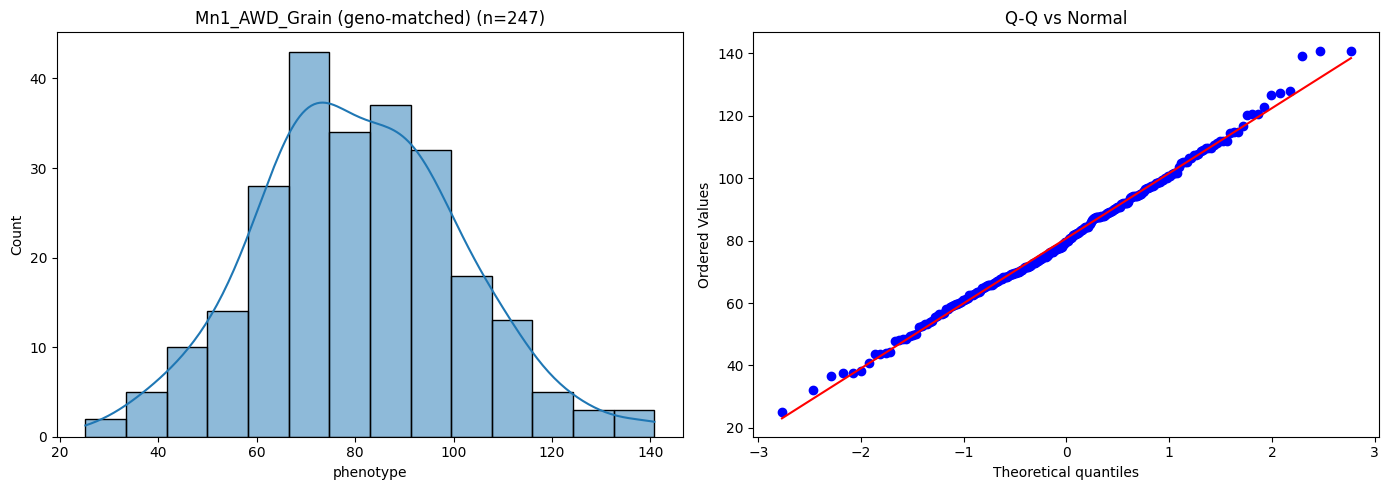

[16:27:15] [INFO] Shapiro-Wilk p=0.6525 — normal


In [10]:
# ===================================
# Step 4.2  PHENOTYPE DISTRIBUTION
# ===================================

if CHECK_PHENOTYPE_DISTRIBUTION:
    # Use only genotype-matched samples so diagnostics/transforms match downstream GWAS cohort.
    common_ids = pheno_series.index.intersection(geno_df.index)
    pheno_matched = pheno_series.loc[common_ids]
    log_message(f"Phenotype records: total non-missing={int(pheno_series.dropna().shape[0])}, matched-to-genotype non-missing={int(pheno_matched.dropna().shape[0])}")

    if len(common_ids) == 0:
        raise ValueError("No overlapping sample IDs between genotype and phenotype for distribution check.")

    # Carry matched phenotype forward so transformation is learned on the analysis cohort only.
    pheno_series = pheno_matched

    if TRAIT_TYPE == 'binary':
        log_message("Binary trait - showing class counts on genotype-matched samples.")
        plt.figure(figsize=(5,3))
        pheno_series.value_counts().plot(kind='bar')
        plt.title(f"Binary Trait: {TRAIT_NAME}"); plt.show()
    else:
        is_skewed = check_phenotype_distribution(pheno_series, f"{TRAIT_NAME} (geno-matched)")
        if is_skewed and TRANSFORM_PHENOTYPE_IF_SKEWED:
            pheno_series, tname = apply_best_phenotype_transformation(pheno_series)
            if tname != "none":
                log_message(f"Re-checking after '{tname}' transform (geno-matched):")
                check_phenotype_distribution(pheno_series, f"{TRAIT_NAME} ({tname}, geno-matched)")
        elif is_skewed:
            log_message("Hint: set TRANSFORM_PHENOTYPE_IF_SKEWED=True to auto-correct skew.", "WARNING")

In [11]:
# ========================
# Step 4.3  QUALITY CONTROL
# ========================

# Convert pandas nullable integer dtypes (pd.NA) to NumPy float/np.nan for QC math.
geno_df = geno_df.astype(np.float64)

G_qc, y, qc_snp_ids, snp_metadata, cov_matrix, qc_report = perform_qc_plink_style(
    geno_df, pheno_series, snp_meta_base,
    maf_threshold    = MAF_THRESHOLD,
    imputation_method= IMPUTATION_METHOD,
    min_snps_per_chrom= MIN_SNPS_PER_CHROMOSOME,
    drop_missing_phenotypes= DROP_MISSING_PHENOTYPES,
    remove_outliers  = REMOVE_PHENOTYPE_OUTLIERS,
    outlier_method   = OUTLIER_METHOD,
    outlier_threshold= OUTLIER_THRESHOLD,
    covariate_df     = covariate_df,
    sample_callrate  = SAMPLE_CALLRATE_THRESHOLD,
    het_rate_filter  = HET_RATE_FILTER,
    het_rate_n_sd    = HET_RATE_N_SD,
    snp_callrate     = SNP_CALLRATE_THRESHOLD,
    run_hwe          = RUN_HWE_FILTER,
    hwe_p            = HWE_P_THRESHOLD,
)

consolidated_qc_summary(qc_report)
report_phenotype_outliers(qc_report)
report_sample_dropout(qc_report)
report_snp_dropout(qc_report)
check_memory("QC done")

# --- Optional: Beagle imputation ---
if RUN_BEAGLE_IMPUTATION:
    G_qc = run_beagle_imputation(G_qc, qc_snp_ids, snp_metadata,
                                 beagle_jar=BEAGLE_JAR, java_mem=BEAGLE_JAVA_MEM,
                                 ne=BEAGLE_NE, output_prefix=OUTPUT_PREFIX)
    check_memory("Beagle")

# --- Optional: LD pruning for PCA/kinship ---
if LD_PRUNE_BEFORE_PCA:
    pruned_mask = ld_prune(G_qc, LD_PRUNE_WINDOW_SIZE, LD_PRUNE_STEP_SIZE, LD_PRUNE_R2_THRESHOLD)
    G_pruned = G_qc[:, pruned_mask]
    log_message(f"LD-pruned -> {G_pruned.shape[1]}/{G_qc.shape[1]} SNPs for PCA")
else:
    G_pruned = G_qc

log_message(f"G_qc: {G_qc.shape}   y: {len(y)}   covariates: {cov_matrix.shape if cov_matrix is not None else None}")

[16:27:17] [INFO] Sample QC: 260 -> 260 (removed 0 — callrate<0.9: 0, het outlier: 0)
[16:27:22] [INFO] SNP QC: removed callrate=0, HWE=0, MAF=16825  -> 1983910/2000735 kept
[16:27:40] [INFO] [MEM after QC] RSS=14.57 GB

QC SUMMARY
  Samples initial     : 260
  Removed (sample QC) : 0
  Removed (no pheno)  : 13
  Removed (outliers)  : 0
  SNPs initial        : 2000735
  Removed all-missing : 0
  Removed callrate    : 0
  Removed HWE         : 0
  Removed MAF         : 16825
  Removed bad chrom   : 0
  Consolidated chr0   : 0
  Final samples       : 247
  Final SNPs          : 1983910

Samples with no phenotype: 13
[16:27:40] [INFO] [MEM QC done] RSS=10.89 GB
[16:28:43] [INFO] LD prune: 252900/1983910 SNPs retained (r²>0.5)
[16:28:43] [INFO] LD-pruned -> 252900/1983910 SNPs for PCA
[16:28:43] [INFO] G_qc: (247, 1983910)   y: 247   covariates: None


In [12]:
# ========================
# Step 4.4  PCA
# ========================

PCs, num_pcs_used = run_pca(G_pruned, NUM_PCS, AUTO_SELECT_PCS)
log_message(f"Using {num_pcs_used} PCs.")
check_memory("PCA")

# clean up pruned copy
if LD_PRUNE_BEFORE_PCA and G_pruned is not G_qc:
    del G_pruned; gc.collect()


[16:28:46] [INFO] PCA done — using 5 PCs
[16:28:46] [INFO] Using 5 PCs.
[16:28:46] [INFO] [MEM PCA] RSS=11.49 GB


[16:28:46] [INFO] === Naive GLM ===
[16:28:46] [INFO] Running Naive GLM (continuous)…
[16:28:53] [INFO]   20000/1983910 SNPs
[16:28:53] [INFO] [MEM naive] RSS=11.02 GB
[16:29:01] [INFO]   40000/1983910 SNPs
[16:29:01] [INFO] [MEM naive] RSS=11.02 GB
[16:29:08] [INFO]   60000/1983910 SNPs
[16:29:08] [INFO] [MEM naive] RSS=11.02 GB
[16:29:16] [INFO]   80000/1983910 SNPs
[16:29:16] [INFO] [MEM naive] RSS=11.02 GB
[16:29:24] [INFO]   100000/1983910 SNPs
[16:29:24] [INFO] [MEM naive] RSS=11.02 GB
[16:29:31] [INFO]   120000/1983910 SNPs
[16:29:31] [INFO] [MEM naive] RSS=11.02 GB
[16:29:39] [INFO]   140000/1983910 SNPs
[16:29:39] [INFO] [MEM naive] RSS=11.02 GB
[16:29:46] [INFO]   160000/1983910 SNPs
[16:29:46] [INFO] [MEM naive] RSS=11.02 GB
[16:29:54] [INFO]   180000/1983910 SNPs
[16:29:54] [INFO] [MEM naive] RSS=11.02 GB
[16:30:01] [INFO]   200000/1983910 SNPs
[16:30:01] [INFO] [MEM naive] RSS=11.02 GB
[16:30:09] [INFO]   220000/1983910 SNPs
[16:30:09] [INFO] [MEM naive] RSS=11.02 GB
[16:3

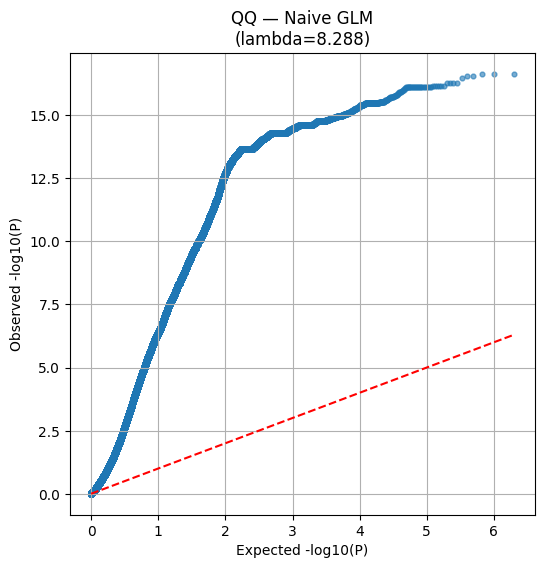

[16:41:54] [INFO] Interactive manhattan naive saved -> /work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_manhattan_naive.html
Open interactive manhattan naive: file:///work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_manhattan_naive.html


[16:41:54] [INFO] === PCA-Corrected GLM ===
[16:41:54] [INFO] Running PCA-corrected GLM (continuous)…
[16:42:02] [INFO]   20000/1983910 SNPs
[16:42:02] [INFO] [MEM pca-glm] RSS=12.04 GB
[16:42:10] [INFO]   40000/1983910 SNPs
[16:42:10] [INFO] [MEM pca-glm] RSS=12.04 GB
[16:42:18] [INFO]   60000/1983910 SNPs
[16:42:18] [INFO] [MEM pca-glm] RSS=12.04 GB
[16:42:26] [INFO]   80000/1983910 SNPs
[16:42:26] [INFO] [MEM pca-glm] RSS=12.04 GB
[16:42:34] [INFO]   100000/1983910 SNPs
[16:42:34] [INFO] [MEM pca-glm] RSS=12.04 GB
[16:42:42] [INFO]   120000/1983910 SNPs
[16:42:42] [INFO] [MEM pca-glm] RSS=12.04 GB
[16:42:50] [INFO]   140000/1983910 SNPs
[16:42:50] [INFO] [MEM pca-glm] RSS=12.04 GB
[16:42:58] [INFO]   160000/1983910 SNPs
[16:42:58] [INFO] [MEM pca-glm] RSS=12.04 GB
[16:43:06] [INFO]   180000/1983910 SNPs
[16:43:06] [INFO] [MEM pca-glm] RSS=12.04 GB
[16:43:14] [INFO]   200000/1983910 SNPs
[16:43:14] [INFO] [MEM pca-glm] RSS=12.04 GB
[16:43:23] [INFO]   220000/1983910 SNPs
[16:43:23] [

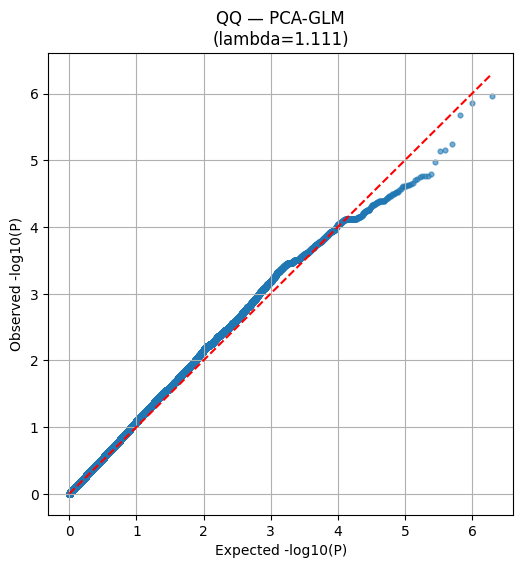

[16:55:53] [INFO] Interactive manhattan pca saved -> /work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_manhattan_pca.html
Open interactive manhattan pca: file:///work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_manhattan_pca.html


[16:55:53] [INFO] === EMMAX (P3D) ===
[16:55:53] [INFO] Running LMM…
[16:56:40] [INFO]     99195/1983910 tested
[16:56:40] [INFO] [MEM LMM] RSS=16.61 GB
[16:57:25] [INFO]     198390/1983910 tested
[16:57:25] [INFO] [MEM LMM] RSS=16.61 GB
[16:58:10] [INFO]     297585/1983910 tested
[16:58:10] [INFO] [MEM LMM] RSS=16.61 GB
[16:58:57] [INFO]     396780/1983910 tested
[16:58:57] [INFO] [MEM LMM] RSS=16.61 GB
[16:59:44] [INFO]     495975/1983910 tested
[16:59:44] [INFO] [MEM LMM] RSS=16.61 GB
[17:00:31] [INFO]     595170/1983910 tested
[17:00:31] [INFO] [MEM LMM] RSS=16.61 GB
[17:01:19] [INFO]     694365/1983910 tested
[17:01:19] [INFO] [MEM LMM] RSS=16.61 GB
[17:02:05] [INFO]     793560/1983910 tested
[17:02:05] [INFO] [MEM LMM] RSS=16.61 GB
[17:02:51] [INFO]     892755/1983910 tested
[17:02:51] [INFO] [MEM LMM] RSS=16.61 GB
[17:03:36] [INFO]     991950/1983910 tested
[17:03:36] [INFO] [MEM LMM] RSS=16.61 GB
[17:04:21] [INFO]     1091145/1983910 tested
[17:04:21] [INFO] [MEM LMM] RSS=16.61

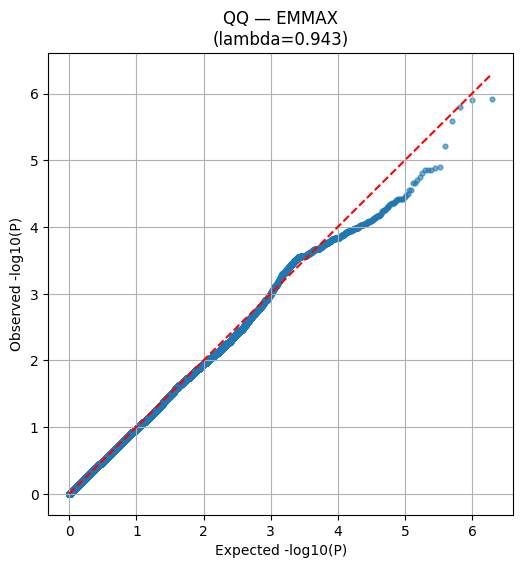

[17:11:48] [INFO] Interactive manhattan emmax saved -> /work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_manhattan_emmax.html
Open interactive manhattan emmax: file:///work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_manhattan_emmax.html


[17:11:48] [INFO] === LMM ===
[17:11:48] [INFO] Running LMM…
[17:12:36] [INFO]     99195/1983910 tested
[17:12:36] [INFO] [MEM LMM] RSS=17.60 GB
[17:13:22] [INFO]     198390/1983910 tested
[17:13:22] [INFO] [MEM LMM] RSS=17.60 GB
[17:14:08] [INFO]     297585/1983910 tested
[17:14:08] [INFO] [MEM LMM] RSS=17.60 GB
[17:14:54] [INFO]     396780/1983910 tested
[17:14:54] [INFO] [MEM LMM] RSS=17.60 GB
[17:15:40] [INFO]     495975/1983910 tested
[17:15:40] [INFO] [MEM LMM] RSS=17.60 GB
[17:16:27] [INFO]     595170/1983910 tested
[17:16:27] [INFO] [MEM LMM] RSS=17.60 GB
[17:17:13] [INFO]     694365/1983910 tested
[17:17:13] [INFO] [MEM LMM] RSS=17.60 GB
[17:17:59] [INFO]     793560/1983910 tested
[17:17:59] [INFO] [MEM LMM] RSS=17.60 GB
[17:18:45] [INFO]     892755/1983910 tested
[17:18:45] [INFO] [MEM LMM] RSS=17.60 GB
[17:19:31] [INFO]     991950/1983910 tested
[17:19:31] [INFO] [MEM LMM] RSS=17.60 GB
[17:20:17] [INFO]     1091145/1983910 tested
[17:20:17] [INFO] [MEM LMM] RSS=17.60 GB
[17:

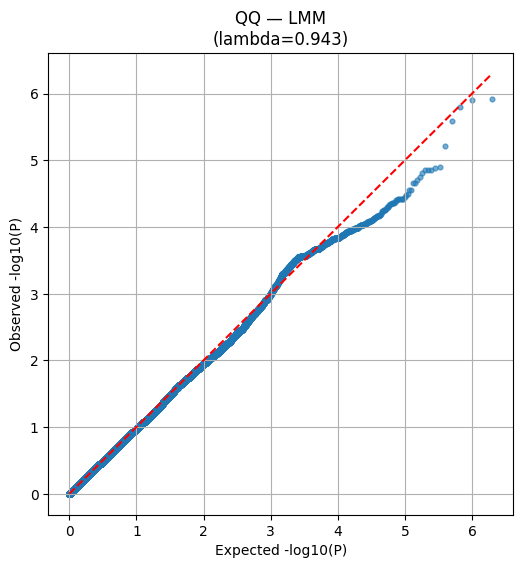

[17:27:51] [INFO] Interactive manhattan lmm saved -> /work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_manhattan_lmm.html
Open interactive manhattan lmm: file:///work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_manhattan_lmm.html



External model status:


,model,status
0,BLINK,SKIPPED
1,FARMCPU,SKIPPED
2,MRMLM,SKIPPED



--- Results preview ---


,SNP_ID,chrom,pos,p_value_naive,beta_naive,se_naive,p_value_pca,beta_pca,se_pca,p_value_emmax,beta_emmax,se_emmax,p_value_lmm,beta_lmm,se_lmm
0,1:1178,1,1178,1.142723e-04,-5.765039,1.470093,0.666628,0.746444,1.730633,0.606993,0.960976,1.865795,0.606993,0.960976,1.865795
1,1:1184,1,1184,3.978416e-10,-11.970014,1.835839,0.308388,3.686661,3.611620,0.431844,3.079320,3.910906,0.431844,3.079320,3.910906
2,1:1203,1,1203,3.469428e-09,-10.724075,1.749131,0.675878,1.244280,2.972435,0.478677,2.310649,3.256538,0.478677,2.310649,3.256538
3,1:1249,1,1249,5.654798e-11,-11.894205,1.734367,0.871787,-0.514620,3.185283,0.803369,0.929318,3.728239,0.803369,0.929318,3.728239
4,1:1277,1,1277,1.610680e-06,-7.896515,1.605938,0.425131,1.697256,2.124457,0.375735,1.981773,2.233155,0.375735,1.981773,2.233155


[17:27:51] [INFO] [MEM GWAS models done] RSS=13.44 GB


In [13]:

# ===================================
# Step 4.5a  RUN GWAS MODELS
# ===================================

results_df = snp_metadata.copy()
qq_data = {}

if RUN_NAIVE_GLM:
    log_message("=== Naive GLM ===")
    p_naive, b_naive, se_naive = run_gwas_naive(G_qc, y, covariates=cov_matrix)
    results_df['p_value_naive'] = p_naive
    results_df['beta_naive']    = b_naive
    results_df['se_naive']      = se_naive
    qq_data['Naive GLM'] = p_naive
    plot_qq(p_naive, "QQ — Naive GLM")
    try:
        fig = interactive_plots.create_interactive_manhattan(results_df, 'p_value_naive', title="Manhattan — Naive GLM")
        if fig:
            save_interactive_plot(fig, f"{OUTPUT_PREFIX}_manhattan_naive.html", label="manhattan naive")
    except Exception as e: log_message(f"Interactive plot error: {e}", "WARNING")

if RUN_PCA_GLM:
    log_message("=== PCA-Corrected GLM ===")
    p_pca, b_pca, se_pca = run_gwas_pca(G_qc, y, PCs, covariates=cov_matrix)
    results_df['p_value_pca'] = p_pca
    results_df['beta_pca']    = b_pca
    results_df['se_pca']      = se_pca
    qq_data['PCA-GLM'] = p_pca
    plot_qq(p_pca, "QQ — PCA-GLM")
    try:
        fig = interactive_plots.create_interactive_manhattan(results_df, 'p_value_pca', title="Manhattan — PCA-GLM")
        if fig:
            save_interactive_plot(fig, f"{OUTPUT_PREFIX}_manhattan_pca.html", label="manhattan pca")
    except Exception as e: log_message(f"Interactive plot error: {e}", "WARNING")

if RUN_EMMAX:
    log_message("=== EMMAX (P3D) ===")
    p_emmax, b_emmax, se_emmax = run_gwas_emmax(G_qc, y, PCs, snp_metadata, covariates=cov_matrix)
    results_df['p_value_emmax'] = p_emmax
    results_df['beta_emmax']    = b_emmax
    results_df['se_emmax']      = se_emmax
    qq_data['EMMAX'] = p_emmax
    plot_qq(p_emmax, "QQ — EMMAX")
    try:
        fig = interactive_plots.create_interactive_manhattan(results_df, 'p_value_emmax', title="Manhattan — EMMAX")
        if fig:
            save_interactive_plot(fig, f"{OUTPUT_PREFIX}_manhattan_emmax.html", label="manhattan emmax")
    except Exception as e: log_message(f"Interactive plot error: {e}", "WARNING")

if RUN_LMM:
    log_message("=== LMM ===")
    p_lmm, b_lmm, se_lmm = run_gwas_lmm(G_qc, y, PCs, snp_metadata, loco=False, covariates=cov_matrix)
    results_df['p_value_lmm'] = p_lmm
    results_df['beta_lmm']    = b_lmm
    results_df['se_lmm']      = se_lmm
    qq_data['LMM'] = p_lmm
    plot_qq(p_lmm, "QQ — LMM")
    try:
        fig = interactive_plots.create_interactive_manhattan(results_df, 'p_value_lmm', title="Manhattan — LMM")
        if fig:
            save_interactive_plot(fig, f"{OUTPUT_PREFIX}_manhattan_lmm.html", label="manhattan lmm")
    except Exception as e: log_message(f"Interactive plot error: {e}", "WARNING")

if RUN_LOCO_LMM:
    log_message("=== LOCO-LMM ===")
    p_loco, b_loco, se_loco = run_gwas_lmm(G_qc, y, PCs, snp_metadata, loco=True, covariates=cov_matrix)
    results_df['p_value_loco'] = p_loco
    results_df['beta_loco']    = b_loco
    results_df['se_loco']      = se_loco
    qq_data['LOCO-LMM'] = p_loco
    plot_qq(p_loco, "QQ — LOCO-LMM")
    try:
        fig = interactive_plots.create_interactive_manhattan(results_df, 'p_value_loco', title="Manhattan — LOCO-LMM")
        if fig:
            save_interactive_plot(fig, f"{OUTPUT_PREFIX}_manhattan_loco.html", label="manhattan loco")
    except Exception as e: log_message(f"Interactive plot error: {e}", "WARNING")

if RUN_MLM_STEPWISE:
    log_message("=== Stepwise MLM ===")
    p_mlm, b_mlm, se_mlm = run_gwas_mlm_stepwise(G_qc, y, PCs, snp_metadata, covariates=cov_matrix)
    results_df['p_value_mlm'] = p_mlm
    results_df['beta_mlm']    = b_mlm
    results_df['se_mlm']      = se_mlm
    qq_data['MLM-Stepwise'] = p_mlm
    plot_qq(p_mlm, "QQ — Stepwise MLM")
    try:
        fig = interactive_plots.create_interactive_manhattan(results_df, 'p_value_mlm', title="Manhattan — Stepwise MLM")
        if fig:
            save_interactive_plot(fig, f"{OUTPUT_PREFIX}_manhattan_mlm.html", label="manhattan mlm")
    except Exception as e: log_message(f"Interactive plot error: {e}", "WARNING")

external_model_status = []
for _ext_model in ['blink', 'farmcpu', 'mrmlm']:
    _run_flag = bool(globals().get(f'RUN_{_ext_model.upper()}', False))
    if not _run_flag:
        external_model_status.append({'model': _ext_model.upper(), 'status': 'SKIPPED'})
        continue

    _t0 = time.time()
    ext_prefix = f"{OUTPUT_PREFIX}_{_ext_model}"
    ext_df = run_external_r_model(
        model_name=_ext_model,
        geno_format=GENO_FORMAT,
        geno_path=GENO_PATH,
        pheno_path=PHENO_PATH,
        trait_name=TRAIT_NAME,
        output_prefix=ext_prefix,
        covariate_path=COVARIATE_PATH,
    )
    if ext_df is None or ext_df.empty:
        raise RuntimeError(f"External model {_ext_model.upper()} returned no rows (fallback disabled).")

    _merge = ext_df.set_index('SNP_ID')
    _snp_id_series = results_df['SNP_ID'].astype(str)
    results_df[f'p_value_{_ext_model}'] = _snp_id_series.map(_merge['p_value'])
    results_df[f'beta_{_ext_model}'] = _snp_id_series.map(_merge['beta'])
    results_df[f'se_{_ext_model}'] = _snp_id_series.map(_merge['se'])

    _pv = results_df[f'p_value_{_ext_model}'].dropna().values
    external_model_status.append({'model': _ext_model.upper(), 'status': 'OK', 'mapped_p': int(len(_pv)), 'seconds': round(time.time()-_t0, 2)})
    if len(_pv) == 0:
        raise RuntimeError(f"External model {_ext_model.upper()} mapped 0 p-values to SNP_ID; cannot continue.")

    qq_data[_ext_model.upper()] = _pv
    plot_qq(_pv, f"QQ — {_ext_model.upper()}")
    try:
        fig = interactive_plots.create_interactive_manhattan(results_df, f'p_value_{_ext_model}', title=f"Manhattan — {_ext_model.upper()}")
        if fig:
            save_interactive_plot(fig, f"{OUTPUT_PREFIX}_manhattan_{_ext_model}.html", label=f"manhattan {_ext_model}")
    except Exception as e:
        log_message(f"Interactive Manhattan failed for {_ext_model.upper()}: {e}", "WARNING")

if external_model_status:
    print("\nExternal model status:")
    display(pd.DataFrame(external_model_status))

print("\n--- Results preview ---")
display(results_df.head())
check_memory("GWAS models done")


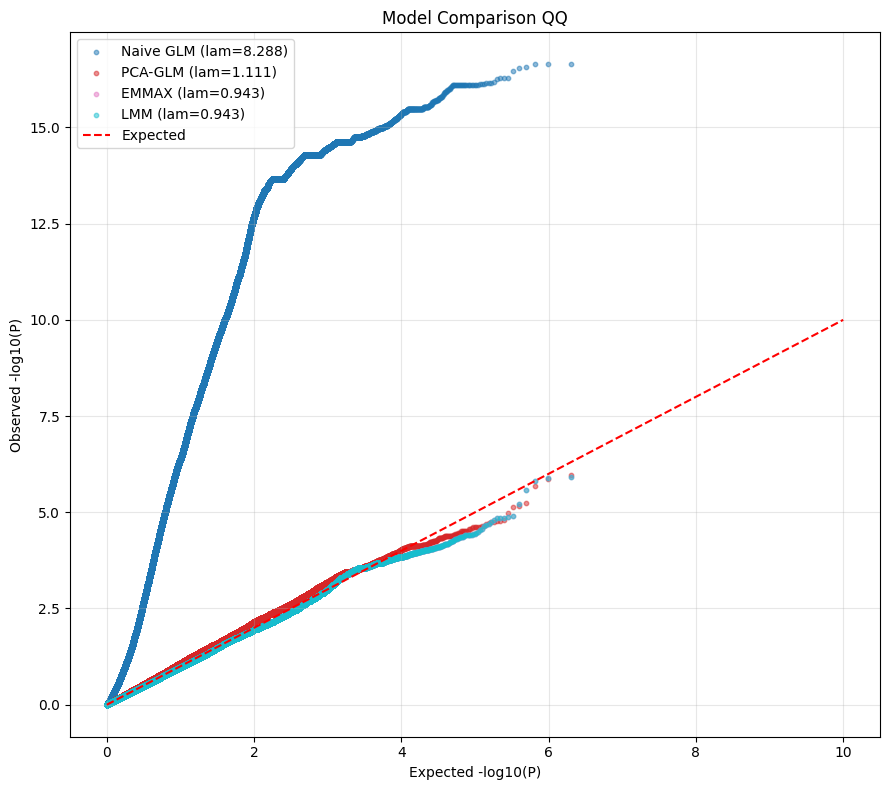


GENOMIC INFLATION (lambda)
  Naive GLM                : lambda=8.288  [HIGH]
  PCA-GLM                  : lambda=1.111  [HIGH]
  EMMAX                    : lambda=0.943  [LOW]
  LMM                      : lambda=0.943  [LOW]

  Best calibrated: EMMAX


In [14]:
# ===================================
# Step 4.5b  MODEL COMPARISON
# ===================================

def plot_comparative_qq(qq_dict):
    n = len(qq_dict)
    if n == 0: return {}
    lam_vals = {}
    for name, pv in qq_dict.items():
        pc = pd.Series(pv).dropna()
        if pc.empty: continue
        chi = stats.chi2.ppf(1 - pc, 1)
        lam_vals[name] = np.median(chi) / stats.chi2.ppf(0.5, 1)

    if n > 1:
        cols = plt.cm.tab10(np.linspace(0,1,n))
        plt.figure(figsize=(9,8))
        for i, (name, pv) in enumerate(qq_dict.items()):
            pc = pd.Series(pv).dropna()
            if pc.empty: continue
            ps = np.sort(pc)
            obs = -np.log10(ps)
            exp = -np.log10(np.arange(1,len(ps)+1)/(len(ps)+1))
            lv = lam_vals.get(name, float('nan'))
            plt.scatter(exp, obs, s=10, alpha=.5, label=f"{name} (lam={lv:.3f})", color=cols[i])
        mx = max(exp.max() for _ in [1])  # simple
        plt.plot([0, 10], [0, 10], 'r--', label='Expected')
        plt.xlabel("Expected -log10(P)"); plt.ylabel("Observed -log10(P)")
        plt.title("Model Comparison QQ"); plt.legend(loc='upper left'); plt.grid(alpha=.3)
        plt.tight_layout(); plt.show()

    print("\n" + "="*50)
    print("GENOMIC INFLATION (lambda)")
    print("="*50)
    for name, lv in lam_vals.items():
        tag = "OK" if 0.95<=lv<=1.05 else ("HIGH" if lv>1.05 else "LOW")
        print(f"  {name:25s}: lambda={lv:.3f}  [{tag}]")
    if lam_vals:
        best = min(lam_vals, key=lambda k: abs(lam_vals[k]-1))
        print(f"\n  Best calibrated: {best}")
    return lam_vals

lambda_values = plot_comparative_qq(qq_data) if qq_data else {}


In [15]:
# ===================================
# Step 4.6  FDR CORRECTION & SUMMARY
# ===================================

n_snps_final = G_qc.shape[1]
bonferroni_threshold = SIGNIFICANCE_ALPHA / n_snps_final
summary_data = []

model_methods = []
if RUN_NAIVE_GLM:    model_methods.append('naive')
if RUN_PCA_GLM:      model_methods.append('pca')
if RUN_EMMAX:        model_methods.append('emmax')
if RUN_LMM:          model_methods.append('lmm')
if RUN_LOCO_LMM:     model_methods.append('loco')
if RUN_MLM_STEPWISE: model_methods.append('mlm')
if RUN_BLINK:        model_methods.append('blink')
if RUN_FARMCPU:      model_methods.append('farmcpu')
if RUN_MRMLM:        model_methods.append('mrmlm')

for method in model_methods:
    p_col = f'p_value_{method}'; q_col = f'q_value_{method}'
    results_df[q_col] = np.nan
    if p_col not in results_df.columns: continue
    valid = results_df[p_col].notna() & np.isfinite(results_df[p_col])
    if valid.sum() == 0: continue
    try:
        rej, qv, _, _ = multipletests(results_df.loc[valid, p_col].values, alpha=SIGNIFICANCE_ALPHA, method='fdr_bh')
        results_df.loc[valid, q_col] = qv
    except Exception as e:
        log_message(f"FDR failed for {method}: {e}", "WARNING"); continue

    bonf_n = (results_df[p_col] < bonferroni_threshold).sum()
    fdr_n  = (results_df[q_col] < SIGNIFICANCE_ALPHA).sum() if q_col in results_df.columns else 0
    summary_data.append({
        "Model": method.upper(), "Tested": int(valid.sum()),
        f"Bonf (p<{bonferroni_threshold:.1e})": int(bonf_n),
        f"FDR (q<{SIGNIFICANCE_ALPHA})": int(fdr_n),
        "Min P": f"{results_df[p_col].min():.2e}",
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*60); print("GWAS SUMMARY"); print("="*60)
if not summary_df.empty:
    print(summary_df.to_string(index=False))

# Save
out_csv = f"{OUTPUT_PREFIX}_gwas_results.csv"
results_df.to_csv(out_csv, index=False)
log_message(f"Results saved -> {out_csv}")

# ── Model recommendation ─────────────────────────────────────────────
best_model_name = None
if 'lambda_values' in dir() and lambda_values:
    best_readable = min(lambda_values.keys(), key=lambda k: abs(lambda_values[k] - 1))
    lk_inv = {'Naive GLM':'NAIVE','PCA-GLM':'PCA','EMMAX':'EMMAX','LMM':'LMM','LOCO-LMM':'LOCO','MLM-Stepwise':'MLM','BLINK':'BLINK','FARMCPU':'FARMCPU','MRMLM':'MRMLM'}
    if best_readable in lk_inv:
        best_model_name = lk_inv[best_readable]

if not best_model_name:
    pref = ['blink','farmcpu','mrmlm','mlm','loco','emmax','lmm','pca','naive']
    for m in pref:
        if m.upper() in summary_df['Model'].values if not summary_df.empty else []:
            best_model_name = m.upper(); break
if best_model_name:
    lk = {'NAIVE':'Naive GLM','PCA':'PCA-GLM','EMMAX':'EMMAX','LMM':'LMM','LOCO':'LOCO-LMM','MLM':'MLM-Stepwise','BLINK':'BLINK','FARMCPU':'FARMCPU','MRMLM':'MRMLM'}
    lam_k = lk.get(best_model_name,'')
    lam_v = lambda_values.get(lam_k) if 'lambda_values' in dir() else None
    lam_s = f" (lambda={lam_v:.3f})" if lam_v else ""
    print(f"\n  Recommended model: {best_model_name}{lam_s}")
else:
    print("\n  No model completed successfully.")



GWAS SUMMARY
Model  Tested  Bonf (p<5.0e-08)  FDR (q<0.1)    Min P
NAIVE 1983910            146044       982416 2.29e-17
  PCA 1983910                 0            0 1.11e-06
EMMAX 1983910                 0            0 1.20e-06
  LMM 1983910                 0            0 1.20e-06
[17:30:11] [INFO] Results saved -> runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_gwas_results.csv

  Recommended model: EMMAX (lambda=0.943)


In [16]:
# ===================================
# Step 4.7  TOP LOCI, ANNOTATION, COJO, LOCUS-ZOOM, GWAS CATALOG
# ===================================

importlib.reload(interactive_plots)   # pick up new functions

target_model = (best_model_name.lower() if best_model_name else
                ('blink' if RUN_BLINK else ('farmcpu' if RUN_FARMCPU else ('mrmlm' if RUN_MRMLM else ('loco' if RUN_LOCO_LMM else ('emmax' if RUN_EMMAX else ('lmm' if RUN_LMM else ('pca' if RUN_PCA_GLM else 'naive'))))))))
p_col_t = f'p_value_{target_model}'
b_col_t = f'beta_{target_model}'
se_col_t = f'se_{target_model}'

top_loci = pd.DataFrame()
cojo_results = pd.DataFrame()
catalog_results = pd.DataFrame()

if p_col_t in results_df.columns:
    # ------- LD-based clumping (r2) with fallback to distance clumping -------
    try:
        top_loci = interactive_plots.perform_ld_clumping(
            results_df, G_qc, qc_snp_ids, p_col_t,
            r2_threshold=CLUMP_R2_THRESHOLD,
            window_kb=CLUMP_WINDOW_KB,
            p_threshold=CLUMP_P_THRESHOLD,
        )
        log_message(f"LD-based clumping (r2>{CLUMP_R2_THRESHOLD}): {len(top_loci)} independent loci")
    except Exception as e:
        log_message(f"LD clumping failed, falling back to distance clumping: {e}", "WARNING")
        top_loci = interactive_plots.perform_distance_clumping(
            results_df, p_col_t,
            window_kb=CLUMP_FALLBACK_WINDOW_KB,
            p_threshold=CLUMP_FALLBACK_P_THRESHOLD,
        )

    if not top_loci.empty:
        print(f"\n--- TOP LOCI ({target_model.upper()}, LD-clumped) ---")

        # ------- Ensembl annotation -------
        try:
            import requests as _req
            import time as _t
            def _ensembl_species(s):
                m = {'human':'homo_sapiens','rice':'oryza_sativa','mouse':'mus_musculus',
                     'arabidopsis':'arabidopsis_thaliana','maize':'zea_mays'}
                return m.get(s.lower(), s.lower().replace(' ','_'))
            def _annotate_ensembl(df, species, dist_kb=10):
                sp = _ensembl_species(species); srv = "https://rest.ensembl.org"
                adf = df.copy()
                for c in ['Gene_ID','Gene_Symbol','Gene_Name','Dist_Gene']: adf[c] = None
                for idx, row in adf.iterrows():
                    c, p = str(row['chrom']), int(row['pos'])
                    s, e = max(1, p - dist_kb*1000), p + dist_kb*1000
                    url = f"{srv}/overlap/region/{sp}/{c}:{s}-{e}?feature=gene"
                    try:
                        r = _req.get(url, headers={"Content-Type":"application/json"})
                        if not r.ok and not c.startswith('chr'):
                            r = _req.get(f"{srv}/overlap/region/{sp}/chr{c}:{s}-{e}?feature=gene",
                                         headers={"Content-Type":"application/json"})
                        if r.ok:
                            genes = r.json()
                            if genes:
                                best = min(genes, key=lambda g: min(abs(p-g.get('start',p)), abs(p-g.get('end',p))))
                                adf.at[idx,'Gene_ID']     = best.get('id')
                                adf.at[idx,'Gene_Symbol'] = best.get('external_name')
                                adf.at[idx,'Gene_Name']   = best.get('description')
                                gs, ge = best.get('start',p), best.get('end',p)
                                adf.at[idx,'Dist_Gene'] = 0 if gs<=p<=ge else min(abs(p-gs),abs(p-ge))
                        _t.sleep(0.1)
                    except:
                        pass
                return adf
            top_loci = _annotate_ensembl(top_loci, SPECIES, dist_kb=ENSEMBL_ANNOT_DIST_KB)
        except Exception as e:
            log_message(f"Annotation failed: {e}", "WARNING")

        # ------- Display top loci table -------
        show_cols = ['SNP_ID','chrom','pos', p_col_t]
        q_col_t = f'q_value_{target_model}'
        if q_col_t in top_loci.columns: show_cols.append(q_col_t)
        if b_col_t in top_loci.columns: show_cols.append(b_col_t)
        if se_col_t in top_loci.columns: show_cols.append(se_col_t)
        for ac in ['Gene_ID','Gene_Symbol','Gene_Name','Dist_Gene']:
            if ac in top_loci.columns: show_cols.append(ac)
        show_cols = [c for c in show_cols if c in top_loci.columns]
        tl = top_loci[show_cols].copy()
        tl['-log10(P)'] = -np.log10(tl[p_col_t])
        display(tl.head(20))
        tl.to_csv(f"{OUTPUT_PREFIX}_top_loci_{target_model}.csv", index=False)

        # ------- COJO conditional analysis -------
        if RUN_COJO:
            try:
                lead_ids = top_loci['SNP_ID'].tolist()
                cojo_results = interactive_plots.cojo_conditional(
                    results_df, G_qc, y, qc_snp_ids, p_col_t,
                    lead_snp_ids=lead_ids,
                    window_kb=CLUMP_WINDOW_KB,
                    p_cojo=COJO_P_THRESHOLD,
                    max_secondary=COJO_MAX_SECONDARY,
                    covariates=cov_matrix,
                )
                if not cojo_results.empty:
                    print(f"\n--- COJO SECONDARY SIGNALS ({len(cojo_results)} found) ---")
                    display(cojo_results.head(20))
                    cojo_results.to_csv(f"{OUTPUT_PREFIX}_cojo_secondary.csv", index=False)
                else:
                    log_message("COJO: no secondary signals found.")
            except Exception as e:
                log_message(f"COJO failed: {e}", "WARNING")

        # ------- Locus-zoom plots (top N lead SNPs) -------
        if RUN_LOCUS_ZOOM:
            try:
                n_zoom = min(LOCUS_ZOOM_N_LOCI, len(top_loci))
                for i in range(n_zoom):
                    lead_id = top_loci.iloc[i]['SNP_ID']
                    fig_lz = interactive_plots.create_locus_zoom(
                        results_df, G_qc, qc_snp_ids, lead_id, p_col_t,
                        window_kb=LOCUS_ZOOM_WINDOW_KB,
                    )
                    if fig_lz:
                        html_path = f"{OUTPUT_PREFIX}_locuszoom_{lead_id}.html"
                        save_interactive_plot(fig_lz, html_path, label=f"locus-zoom {lead_id}")
            except Exception as e:
                log_message(f"Locus-zoom failed: {e}", "WARNING")

        # ------- GWAS Catalog lookup -------
        if RUN_GWAS_CATALOG and SPECIES.lower() == 'human':
            try:
                catalog_results = interactive_plots.gwas_catalog_lookup(
                    top_loci, window_bp=GWAS_CATALOG_WINDOW_BP,
                )
                if not catalog_results.empty:
                    print(f"\n--- GWAS CATALOG MATCHES ({len(catalog_results)}) ---")
                    display(catalog_results.head(20))
                    catalog_results.to_csv(f"{OUTPUT_PREFIX}_gwas_catalog.csv", index=False)
                else:
                    log_message("GWAS Catalog: no matches found.")
            except Exception as e:
                log_message(f"GWAS Catalog lookup failed: {e}", "WARNING")
        elif RUN_GWAS_CATALOG and SPECIES.lower() != 'human':
            log_message("GWAS Catalog lookup is only available for human data.", "INFO")

        # ------- Pathway enrichment -------
        if 'Gene_Symbol' in top_loci.columns:
            genes = top_loci['Gene_Symbol'].dropna().unique().tolist()
            if len(genes) >= 3:
                enr = gwas_analytics.perform_pathway_enrichment(genes, species=SPECIES)
                if enr is not None:
                    print("\n--- ENRICHED PATHWAYS ---")
                    display(enr[['Term','Adjusted P-value','Genes']].head(10))
    else:
        log_message("No loci reached suggestive threshold.")
else:
    log_message(f"Column {p_col_t} not found.", "WARNING")

[17:30:13] [INFO] LD-based clumping (r2>0.1): 31 independent loci

--- TOP LOCI (EMMAX, LD-clumped) ---


,SNP_ID,chrom,pos,p_value_emmax,q_value_emmax,beta_emmax,se_emmax,Gene_ID,Gene_Symbol,Gene_Name,Dist_Gene,-log10(P)
0,8:11078180,8,11078180,0.000001,0.730485,-7.302897,1.465610,Os08g0282200,None,None,0,5.920962
1,9:5632746,9,5632746,0.000003,0.730485,12.367758,2.568492,Os09g0275300,None,None,4722,5.584207
2,9:11256526,9,11256526,0.000006,0.730485,10.119788,2.188804,Os09g0353200,None,None,2523,5.209746
3,3:28346018,3,28346018,0.000012,0.730485,7.436530,1.666623,Os03g0705101,None,None,1432,4.903553
4,10:10258364,10,10258364,0.000013,0.730485,7.452786,1.674521,Os10g0344550,None,None,0,4.882354
5,4:19444015,4,19444015,0.000014,0.730485,-10.511424,2.367877,Os04g0395100,None,None,8673,4.860858
6,6:28435109,6,28435109,0.000016,0.730485,11.506123,2.608476,Os06g0681900,None,None,664,4.808561
7,7:3552142,7,3552142,0.000020,0.730485,13.553301,3.115476,Os07g0165900,OsUCL21,None,3550,4.696494
8,3:14584838,3,14584838,0.000022,0.730485,-11.004744,2.542135,Os03g0371600,OSJNBb0097F01.17,None,5698,4.657335
9,12:25144107,12,25144107,0.000022,0.730485,-9.520504,2.200215,Os12g0598600,None,None,5760,4.653938


[17:30:51] [INFO] Interactive locus-zoom 8:11078180 saved -> /work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_locuszoom_8:11078180.html
Open interactive locus-zoom 8:11078180: file:///work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_locuszoom_8%3A11078180.html


[17:30:54] [INFO] Interactive locus-zoom 9:5632746 saved -> /work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_locuszoom_9:5632746.html
Open interactive locus-zoom 9:5632746: file:///work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_locuszoom_9%3A5632746.html


[17:30:58] [INFO] Interactive locus-zoom 9:11256526 saved -> /work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_locuszoom_9:11256526.html
Open interactive locus-zoom 9:11256526: file:///work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_locuszoom_9%3A11256526.html


Performing pathway enrichment for 10 genes...
Enrichment analysis failed: Invalid organism 'rice'. Valid options are: c. elegans, caenorhabditis elegans, celegans, d. melanogaster, d. rerio, danio rerio, drosophila, drosophila melanogaster, enrichr, fish, fly, h. sapiens, homo sapiens, hs, hsapiens, human, m. musculus, mm, mouse, mus musculus, nematode, s. cerevisiae, saccharomyces, saccharomyces cerevisiae, worm, yeast, zebrafish


In [17]:
# ===================================
# Step 4.7b  POLYGENIC RISK SCORE (PRS) -- Clump + Threshold
# ===================================

if RUN_PRS:
    log_message("Computing PRS (clump + threshold)...")

    prs_thresholds = PRS_P_THRESHOLDS
    prs_batch_size = int(globals().get('PRS_BATCH_SIZE', 2048))
    prs_batch_size = max(128, prs_batch_size)
    snp_id_to_idx = {sid: i for i, sid in enumerate(qc_snp_ids)}

    def _prs_r2(y_true, prs_values):
        if TRAIT_TYPE == 'continuous':
            return float(np.corrcoef(prs_values, y_true)[0, 1] ** 2)
        try:
            X_prs = sm.add_constant(prs_values)
            m_full = sm.Logit(y_true, X_prs).fit(disp=0)
            m_null = sm.Logit(y_true, np.ones_like(y_true)).fit(disp=0)
            lr = -2 * (m_null.llf - m_full.llf)
            n = len(y_true)
            r2_cox = 1 - np.exp(-lr / n)
            r2_max = 1 - np.exp(2 * m_null.llf / n)
            return float(r2_cox / r2_max) if r2_max > 0 else np.nan
        except Exception:
            return np.nan

    def _score_prs_for_indices(sample_idx, sel_idx, sel_beta):
        prs_vals = np.zeros(len(sample_idx), dtype=np.float64)
        row_idx = np.asarray(sample_idx, dtype=int)
        for bstart in range(0, len(sel_idx), prs_batch_size):
            bend = min(bstart + prs_batch_size, len(sel_idx))
            idx_batch = sel_idx[bstart:bend]
            beta_batch = sel_beta[bstart:bend]
            G_batch = np.asarray(G_qc[row_idx, :][:, idx_batch], dtype=np.float64)
            if np.isnan(G_batch).any():
                G_batch = np.nan_to_num(G_batch, nan=0.0)
            prs_vals += G_batch @ beta_batch
            if bstart > 0 and bstart % (prs_batch_size * 5) == 0:
                check_memory('PRS accumulation')
        return prs_vals

    prs_eval_mode = str(globals().get('PRS_EVAL_MODE', 'apparent')).lower()
    prs_eval_mode = prs_eval_mode if prs_eval_mode in ('apparent', 'holdout') else 'apparent'
    if prs_eval_mode == 'holdout' and TRAIT_TYPE != 'continuous':
        log_message("PRS_EVAL_MODE='holdout' currently optimized for continuous traits; using apparent mode for binary.", 'WARNING')
        prs_eval_mode = 'apparent'

    prs_records = []

    if prs_eval_mode == 'holdout':
        holdout_frac = float(globals().get('PRS_HOLDOUT_FRACTION', 0.20))
        holdout_frac = min(max(holdout_frac, 0.05), 0.5)
        holdout_seed = int(globals().get('PRS_HOLDOUT_SEED', RANDOM_SEED))
        weight_model = str(globals().get('PRS_WEIGHT_MODEL', 'pca')).lower()
        weight_model = weight_model if weight_model in ('pca', 'naive') else 'pca'

        n = len(y)
        rng = np.random.default_rng(holdout_seed)
        perm = rng.permutation(n)
        n_test = max(1, int(round(n * holdout_frac)))
        test_idx = perm[:n_test]
        train_idx = perm[n_test:]
        log_message(f"PRS holdout split: train={len(train_idx)} test={len(test_idx)} (frac={holdout_frac:.2f})")

        G_train = np.asarray(G_qc[np.asarray(train_idx), :], dtype=get_float_dtype())
        y_train = np.asarray(y[train_idx], dtype=np.float64)
        cov_train = cov_matrix[np.asarray(train_idx), :] if cov_matrix is not None else None

        if weight_model == 'naive':
            p_train, b_train, _ = run_gwas_naive(G_train, y_train, covariates=cov_train)
        else:
            PCs_train = np.asarray(PCs[np.asarray(train_idx), :], dtype=get_float_dtype())
            p_train, b_train, _ = run_gwas_pca(G_train, y_train, PCs_train, covariates=cov_train)

        prs_assoc_df = pd.DataFrame({'SNP_ID': qc_snp_ids, 'p_train': p_train, 'beta_train': b_train})
        prs_assoc_df.to_csv(f"{OUTPUT_PREFIX}_prs_train_weights.csv", index=False)

        y_train_eval = np.asarray(y[train_idx], dtype=np.float64)
        y_test_eval = np.asarray(y[test_idx], dtype=np.float64)

        for thresh in prs_thresholds:
            mask = prs_assoc_df['p_train'].notna() & np.isfinite(prs_assoc_df['p_train']) & (prs_assoc_df['p_train'] < thresh)
            selected = prs_assoc_df.loc[mask, ['SNP_ID', 'beta_train']].copy()
            if selected.empty:
                prs_records.append({'P_threshold': f"{thresh:.0e}", 'N_SNPs': 0, 'R2_train': np.nan, 'R2_test': np.nan})
                continue
            selected = selected[selected['SNP_ID'].isin(snp_id_to_idx.keys())]
            if selected.empty:
                prs_records.append({'P_threshold': f"{thresh:.0e}", 'N_SNPs': 0, 'R2_train': np.nan, 'R2_test': np.nan})
                continue

            sel_idx = np.array([snp_id_to_idx[s] for s in selected['SNP_ID'].values], dtype=int)
            sel_beta = selected['beta_train'].values.astype(np.float64)
            prs_train = _score_prs_for_indices(train_idx, sel_idx, sel_beta)
            prs_test = _score_prs_for_indices(test_idx, sel_idx, sel_beta)
            prs_train_std = (prs_train - prs_train.mean()) / (prs_train.std() + 1e-12)
            prs_test_std = (prs_test - prs_train.mean()) / (prs_train.std() + 1e-12)
            r2_train = _prs_r2(y_train_eval, prs_train_std)
            r2_test = _prs_r2(y_test_eval, prs_test_std)
            prs_records.append({
                'P_threshold': f"{thresh:.0e}",
                'N_SNPs': int(len(sel_idx)),
                'R2_train': round(r2_train, 6) if np.isfinite(r2_train) else np.nan,
                'R2_test': round(r2_test, 6) if np.isfinite(r2_test) else np.nan,
            })

    else:
        prs_p_col = p_col_t
        prs_b_col = b_col_t
        for thresh in prs_thresholds:
            mask = results_df[prs_p_col].notna() & (results_df[prs_p_col] < thresh)
            selected = results_df[mask].copy()
            if selected.empty or prs_b_col not in selected.columns:
                prs_records.append({'P_threshold': f"{thresh:.0e}", 'N_SNPs': 0, 'R2_score': np.nan, 'Mean_PRS': np.nan, 'Std_PRS': np.nan})
                continue
            sel_snps = [(row['SNP_ID'], row[prs_b_col]) for _, row in selected.iterrows() if row['SNP_ID'] in snp_id_to_idx and np.isfinite(row[prs_b_col])]
            if not sel_snps:
                prs_records.append({'P_threshold': f"{thresh:.0e}", 'N_SNPs': 0, 'R2_score': np.nan, 'Mean_PRS': np.nan, 'Std_PRS': np.nan})
                continue
            prs = np.zeros(G_qc.shape[0], dtype=np.float64)
            sel_idx = np.array([snp_id_to_idx[sid] for sid, _ in sel_snps], dtype=int)
            sel_beta = np.array([beta for _, beta in sel_snps], dtype=np.float64)
            for bstart in range(0, len(sel_idx), prs_batch_size):
                bend = min(bstart + prs_batch_size, len(sel_idx))
                idx_batch = sel_idx[bstart:bend]
                beta_batch = sel_beta[bstart:bend]
                G_batch = np.asarray(G_qc[:, idx_batch], dtype=np.float64)
                if np.isnan(G_batch).any():
                    G_batch = np.nan_to_num(G_batch, nan=0.0)
                prs += G_batch @ beta_batch
                if bstart > 0 and bstart % (prs_batch_size * 5) == 0:
                    check_memory('PRS accumulation')
            prs_std = (prs - prs.mean()) / (prs.std() + 1e-12)
            r2 = _prs_r2(np.asarray(y, dtype=np.float64), prs_std)
            prs_records.append({
                'P_threshold': f"{thresh:.0e}",
                'N_SNPs': len(sel_snps),
                'R2_score': round(r2, 6) if np.isfinite(r2) else np.nan,
                'Mean_PRS': round(prs.mean(), 4),
                'Std_PRS': round(prs.std(), 4),
            })

    prs_summary = pd.DataFrame(prs_records)
    print("\n" + "="*60)
    if prs_eval_mode == 'holdout':
        print("PRS SUMMARY (Holdout Evaluation)")
    else:
        print("PRS SUMMARY (Clump + Threshold)")
    print("="*60)
    display(prs_summary)
    prs_summary.to_csv(f"{OUTPUT_PREFIX}_prs_summary.csv", index=False)

    metric_col = 'R2_test' if ('R2_test' in prs_summary.columns) else 'R2_score'
    valid_prs = prs_summary.dropna(subset=[metric_col])
    if not valid_prs.empty:
        plt.figure(figsize=(8, 5))
        plt.bar(range(len(valid_prs)), valid_prs[metric_col].values,
                tick_label=valid_prs['P_threshold'].astype(str))
        ylabel = "R2 (test PRS vs phenotype)" if metric_col == 'R2_test' else "R2 (PRS vs phenotype)"
        plt.xlabel("P-value threshold"); plt.ylabel(ylabel)
        plt.title("PRS Performance across Thresholds"); plt.xticks(rotation=45)
        plt.tight_layout(); plt.show(); plt.close()

    check_memory("PRS done")
else:
    log_message("PRS skipped (RUN_PRS=False).")

[17:30:58] [INFO] PRS skipped (RUN_PRS=False).


/tmp/ipykernel_18649/2144638024.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cmax = df_p.groupby('chrom')['pos'].max().replace(0, 1)


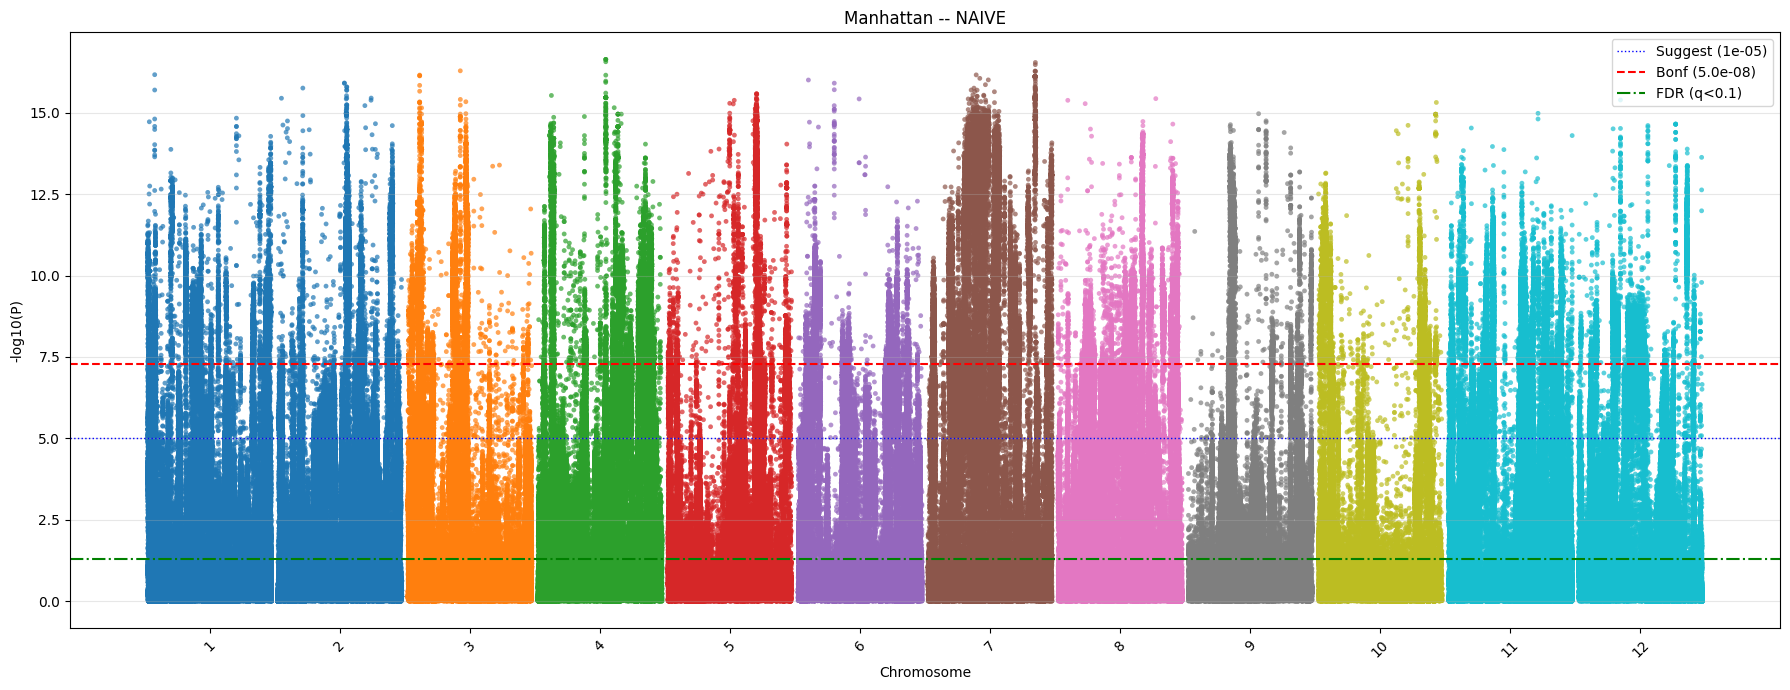

/tmp/ipykernel_18649/2144638024.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cmax = df_p.groupby('chrom')['pos'].max().replace(0, 1)


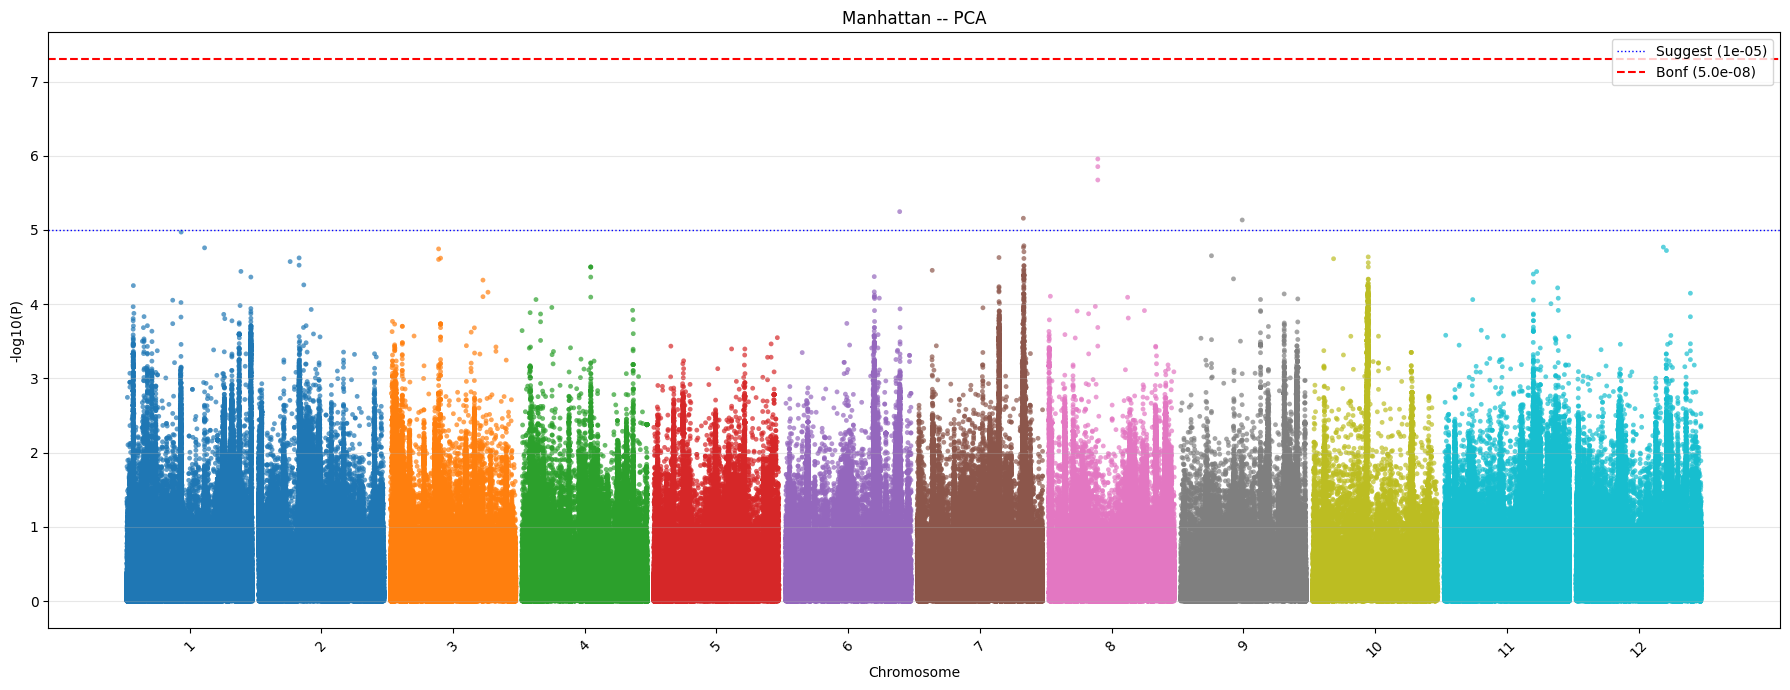

/tmp/ipykernel_18649/2144638024.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cmax = df_p.groupby('chrom')['pos'].max().replace(0, 1)


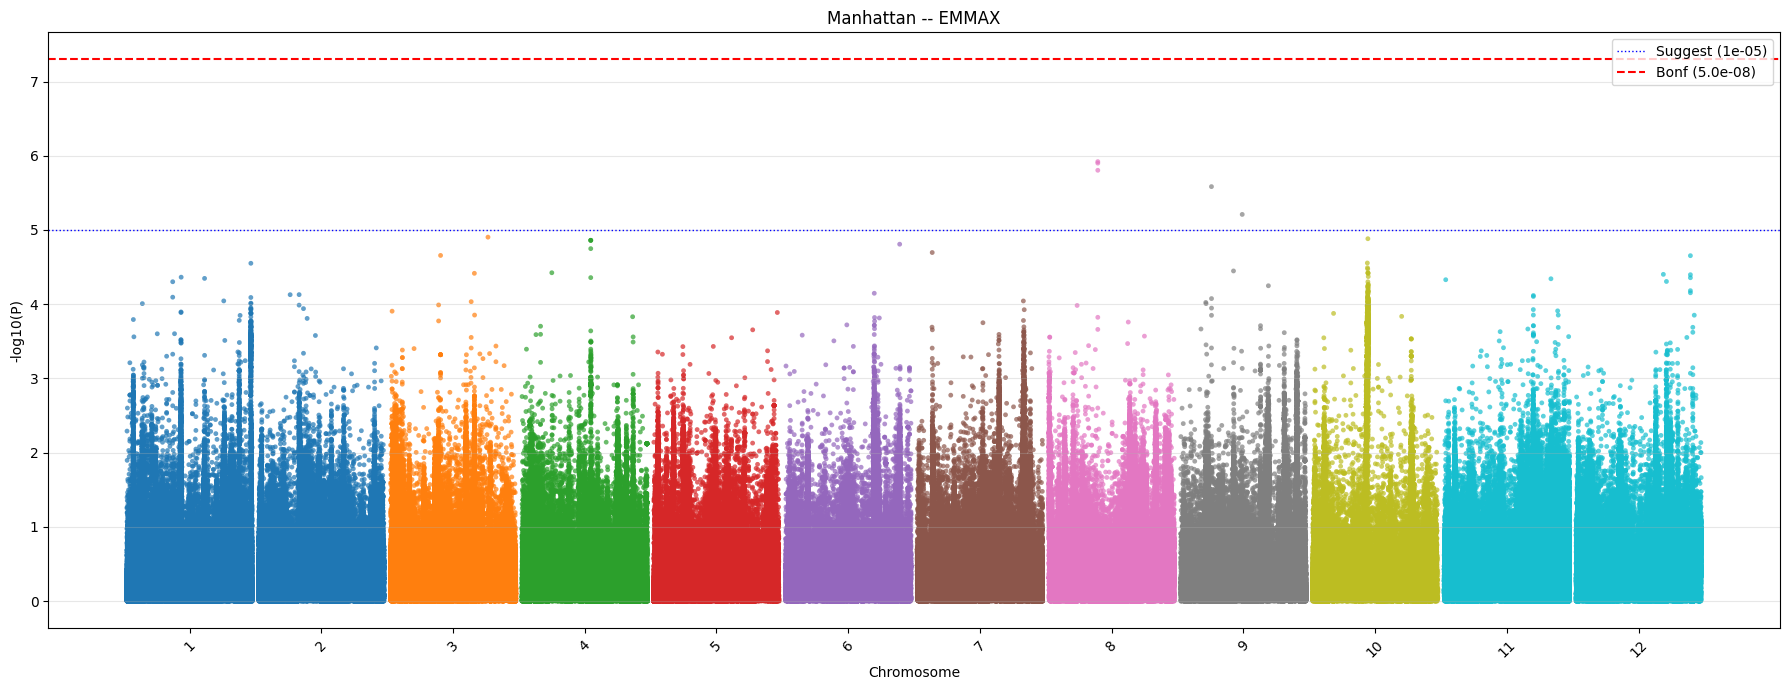

/tmp/ipykernel_18649/2144638024.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cmax = df_p.groupby('chrom')['pos'].max().replace(0, 1)


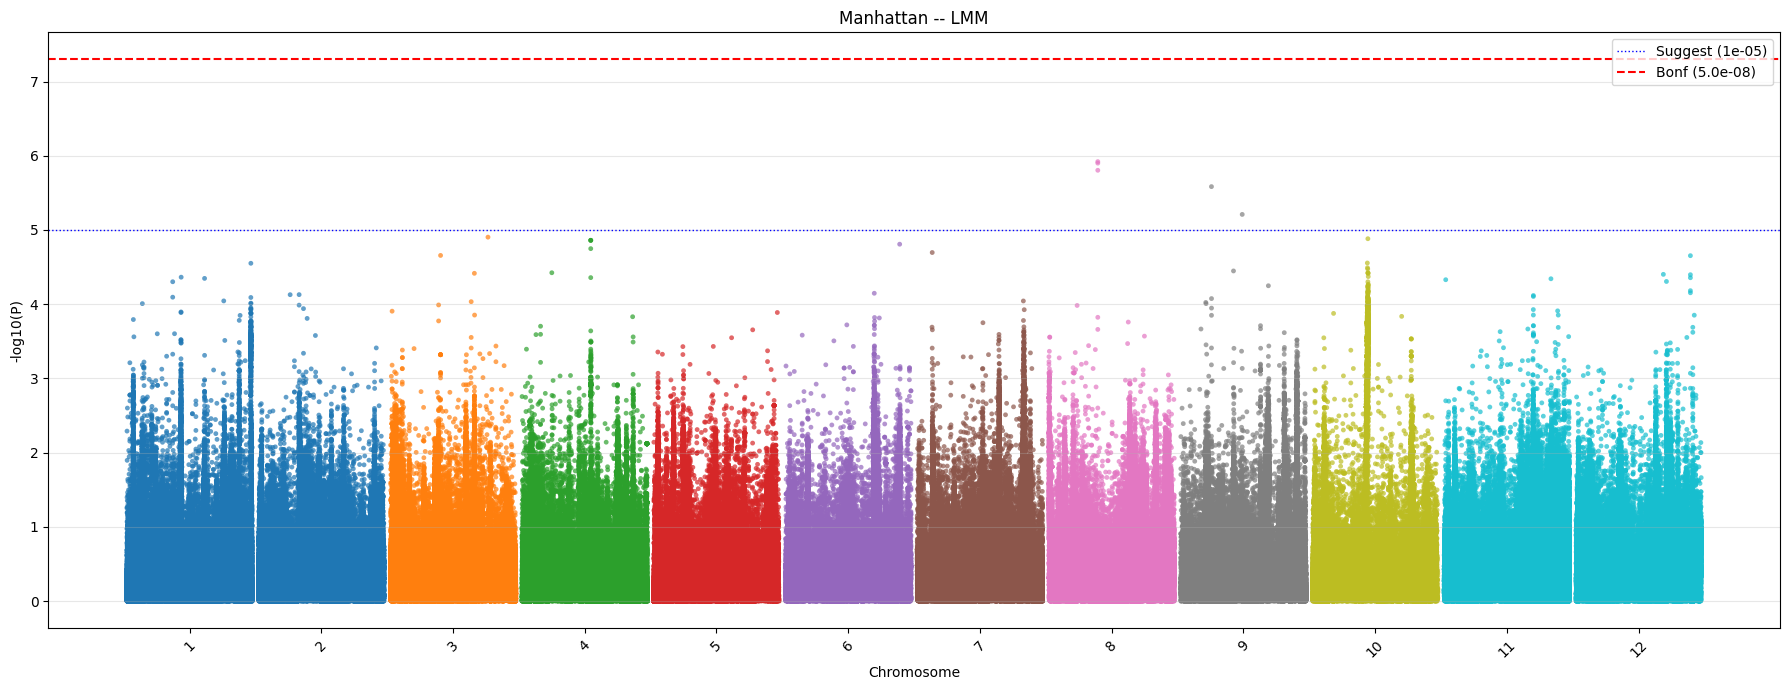

In [18]:
# ===================================
# Step 4.8  MANHATTAN PLOTS
# ===================================

SUGGESTIVE = globals().get('SUGGESTIVE_P_THRESHOLD', 1e-5)
for method in model_methods:
    p_col = f'p_value_{method}'; q_col = f'q_value_{method}'
    if p_col in results_df.columns:
        plot_manhattan(results_df, p_col, q_col,
                       f"Manhattan -- {method.upper()}", bonferroni_threshold, SIGNIFICANCE_ALPHA, SUGGESTIVE)

G_qc_shape = G_qc.shape if isinstance(G_qc, np.ndarray) else None
if bool(globals().get('LOW_RAM_MODE', False)) and isinstance(G_qc, np.ndarray):
    G_qc = None
    gc.collect()
    check_memory('after releasing G_qc post-association')

In [19]:
# ===================================
# 5. BENCHMARKING & SESSION INFO
# ===================================

elapsed = time.time() - start_time
log_message(f"Pipeline finished in {elapsed:.1f}s ({elapsed/60:.1f} min)")
if BENCHMARK:
    _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
    log_message(f"Peak traced memory: {format_bytes(peak)}")

print("\n" + "="*60)
print("SESSION INFO")
print("="*60)
print(f"  Output dir : {os.path.abspath(OUTPUT_DIR)}")
print(f"  Run label  : {RUN_LABEL}")
print(f"  Platform   : {platform.platform()}")
print(f"  Python     : {platform.python_version()}")
print(f"  NumPy      : {np.__version__}")
print(f"  Pandas     : {pd.__version__}")
import scipy; print(f"  SciPy      : {scipy.__version__}")
try: import statsmodels as _sm; print(f"  Statsmodels: {_sm.__version__}")
except: pass
try: import plotly; print(f"  Plotly     : {plotly.__version__}")
except: pass
print(f"  Seed       : {RANDOM_SEED}")
print(f"  Float dtype: {'float32' if FORCE_FLOAT32 else 'float64'}")
print(f"  Inline interactive plots: {SHOW_INTERACTIVE_IN_NOTEBOOK}")
if psutil:
    m = psutil.virtual_memory()
    print(f"  System RAM : {m.total/1024**3:.1f} GB (avail {m.available/1024**3:.1f} GB)")
print(f"  Max mem cfg: {MAX_MEMORY_GB} GB")

cfg_str = f"{GENO_PATH}|{PHENO_PATH}|{COVARIATE_PATH}|{MAF_THRESHOLD}|{RANDOM_SEED}|{NUM_PCS}"
print(f"  Config hash: {hashlib.md5(cfg_str.encode()).hexdigest()[:12]}")
if LOG_TO_FILE: print(f"  Log file   : {LOG_FILE_PATH}")
print("="*60)

# Save config snapshot for reproducibility
_cfg_snapshot = {
    'RUN_LABEL': globals().get('RUN_LABEL', OUTPUT_PREFIX),
    'RUNS_ROOT': RUNS_ROOT,
    'OUTPUT_DIR': OUTPUT_DIR,
    'OUTPUT_PREFIX': OUTPUT_PREFIX,
    'SHOW_INTERACTIVE_IN_NOTEBOOK': SHOW_INTERACTIVE_IN_NOTEBOOK,
    'GENO_PATH': GENO_PATH,
    'GENO_FORMAT': GENO_FORMAT,
    'PHENO_PATH': PHENO_PATH,
    'TRAIT_NAME': TRAIT_NAME,
    'COVARIATE_PATH': COVARIATE_PATH,
    'SPECIES': SPECIES,
    'TRAIT_TYPE': TRAIT_TYPE,
    'MAF_THRESHOLD': MAF_THRESHOLD,
    'IMPUTATION_METHOD': IMPUTATION_METHOD,
    'DROP_MISSING_PHENOTYPES': DROP_MISSING_PHENOTYPES,
    'REMOVE_PHENOTYPE_OUTLIERS': REMOVE_PHENOTYPE_OUTLIERS,
    'OUTLIER_METHOD': OUTLIER_METHOD,
    'OUTLIER_THRESHOLD': OUTLIER_THRESHOLD,
    'CHECK_PHENOTYPE_DISTRIBUTION': CHECK_PHENOTYPE_DISTRIBUTION,
    'TRANSFORM_PHENOTYPE_IF_SKEWED': TRANSFORM_PHENOTYPE_IF_SKEWED,
    'SAMPLE_CALLRATE_THRESHOLD': SAMPLE_CALLRATE_THRESHOLD,
    'SNP_CALLRATE_THRESHOLD': SNP_CALLRATE_THRESHOLD,
    'RUN_IBD_FILTER': RUN_IBD_FILTER,
    'IBD_THRESHOLD': IBD_THRESHOLD,
    'RUN_HWE_FILTER': RUN_HWE_FILTER,
    'HWE_P_THRESHOLD': HWE_P_THRESHOLD,
    'LD_PRUNE_BEFORE_PCA': LD_PRUNE_BEFORE_PCA,
    'LD_PRUNE_R2_THRESHOLD': LD_PRUNE_R2_THRESHOLD,
    'NUM_PCS': NUM_PCS,
    'AUTO_SELECT_PCS': AUTO_SELECT_PCS,
    'RUN_BEAGLE_IMPUTATION': RUN_BEAGLE_IMPUTATION,
    'RUN_NAIVE_GLM': RUN_NAIVE_GLM,
    'RUN_PCA_GLM': RUN_PCA_GLM,
    'RUN_EMMAX': RUN_EMMAX,
    'RUN_LMM': RUN_LMM,
    'RUN_LOCO_LMM': RUN_LOCO_LMM,
    'RUN_MLM_STEPWISE': RUN_MLM_STEPWISE,
    'RUN_BLINK': RUN_BLINK,
    'RUN_FARMCPU': RUN_FARMCPU,
    'RUN_MRMLM': RUN_MRMLM,
    'R_GWAS_CHUNK_SIZE': R_GWAS_CHUNK_SIZE,
    'R_EXECUTABLE': R_EXECUTABLE,
    'SIGNIFICANCE_ALPHA': SIGNIFICANCE_ALPHA,
    'CLUMP_R2_THRESHOLD': CLUMP_R2_THRESHOLD,
    'CLUMP_WINDOW_KB': CLUMP_WINDOW_KB,
    'CLUMP_P_THRESHOLD': CLUMP_P_THRESHOLD,
    'CLUMP_FALLBACK_WINDOW_KB': CLUMP_FALLBACK_WINDOW_KB,
    'CLUMP_FALLBACK_P_THRESHOLD': CLUMP_FALLBACK_P_THRESHOLD,
    'RUN_COJO': RUN_COJO,
    'COJO_P_THRESHOLD': COJO_P_THRESHOLD,
    'RUN_LOCUS_ZOOM': RUN_LOCUS_ZOOM,
    'LOCUS_ZOOM_N_LOCI': LOCUS_ZOOM_N_LOCI,
    'RUN_GWAS_CATALOG': RUN_GWAS_CATALOG,
    'GWAS_CATALOG_WINDOW_BP': GWAS_CATALOG_WINDOW_BP,
    'RUN_PRS': RUN_PRS,
    'PRS_P_THRESHOLDS': PRS_P_THRESHOLDS,
    'PRS_BATCH_SIZE': PRS_BATCH_SIZE,
    'PRS_EVAL_MODE': PRS_EVAL_MODE,
    'PRS_HOLDOUT_FRACTION': PRS_HOLDOUT_FRACTION,
    'PRS_HOLDOUT_SEED': PRS_HOLDOUT_SEED,
    'PRS_WEIGHT_MODEL': PRS_WEIGHT_MODEL,
    'SUGGESTIVE_P_THRESHOLD': SUGGESTIVE_P_THRESHOLD,
    'ENSEMBL_ANNOT_DIST_KB': ENSEMBL_ANNOT_DIST_KB,
    'REPORT_PDF_DPI': REPORT_PDF_DPI,
    'REPORT_PDF_COMPRESSION': REPORT_PDF_COMPRESSION,
    'REPORT_MAX_POINTS': REPORT_MAX_POINTS,
    'REPORT_RASTERIZE_SCATTER': REPORT_RASTERIZE_SCATTER,
    'RANDOM_SEED': RANDOM_SEED,
    'FORCE_FLOAT32': FORCE_FLOAT32,
    'MAX_MEMORY_GB': MAX_MEMORY_GB,
    'LOW_RAM_MODE': globals().get('LOW_RAM_MODE', False),
    'RELEASE_INTERMEDIATE_OBJECTS': RELEASE_INTERMEDIATE_OBJECTS,
}

import json as _json
with open(os.path.join(OUTPUT_DIR, 'config_snapshot.json'), 'w') as _f:
    _json.dump(_cfg_snapshot, _f, indent=2, default=str)
log_message(f"Config snapshot saved -> {OUTPUT_DIR}/config_snapshot.json")

[17:43:31] [INFO] Pipeline finished in 4609.2s (76.8 min)
[17:43:31] [INFO] Peak traced memory: 19.36 GB

SESSION INFO
  Output dir : /work/runs/BAAP_GWAS_v3_output_20260522_162641
  Run label  : BAAP_GWAS_v3_output_20260522_162641
  Platform   : Linux-6.12.76-linuxkit-aarch64-with-glibc2.39
  Python     : 3.12.3
  NumPy      : 1.26.4
  Pandas     : 2.3.3
  SciPy      : 1.17.1
  Statsmodels: 0.14.6
  Plotly     : 6.7.0
  Seed       : 42
  Float dtype: float64
  Inline interactive plots: False
  System RAM : 255.1 GB (avail 236.4 GB)
  Max mem cfg: 200.0 GB
  Config hash: 8896d9ea8d87
  Log file   : runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_pipeline.log
[17:43:31] [INFO] Config snapshot saved -> runs/BAAP_GWAS_v3_output_20260522_162641/config_snapshot.json


In [20]:
# ===================================
# 6. ENHANCED VISUALIZATIONS & PDF REPORT
# ===================================

# Reload gwas_analytics to pick up new generate_summary_report
importlib.reload(gwas_analytics)

# --- 6.1  Volcano plot (real effect sizes) ---
enrichment_result = None
try:
    p_col = f'p_value_{target_model}'
    b_col = f'beta_{target_model}'
    volcano_model = target_model

    # Try preferred model first, then fall back to models with usable beta values.
    fallback_order = [target_model, 'farmcpu', 'mrmlm', 'mlm', 'loco', 'emmax', 'lmm', 'pca', 'naive', 'blink']
    selected = None
    seen = set()

    for m in fallback_order:
        if m in seen:
            continue
        seen.add(m)

        p_try = f'p_value_{m}'
        b_try = f'beta_{m}'

        if p_try not in results_df.columns or b_try not in results_df.columns:
            continue

        p_vals = pd.to_numeric(results_df[p_try], errors='coerce')
        b_vals = pd.to_numeric(results_df[b_try], errors='coerce')
        valid = p_vals.notna() & np.isfinite(p_vals) & b_vals.notna() & np.isfinite(b_vals)
        n_valid = int(valid.sum())

        if n_valid > 0:
            selected = (m, p_try, b_try, n_valid)
            break

    if selected is None:
        print("Volcano plot skipped: no model has both valid p-values and effect sizes (beta).")
        print("Tip: this is common for some external outputs (e.g., BLINK) where beta is all NA.")
    else:
        volcano_model, p_col, b_col, n_valid = selected

        if volcano_model != target_model:
            print(f"Volcano fallback: target model '{target_model.upper()}' has no usable beta values; using '{volcano_model.upper()}' ({n_valid} points).")
        else:
            print(f"Volcano source: {volcano_model.upper()} ({n_valid} points).")

        vfig = interactive_plots.create_interactive_volcano(
            results_df,
            p_col=p_col,
            effect_col=b_col,
            title=f"Volcano -- {TRAIT_NAME} ({volcano_model.upper()})"
        )
        save_interactive_plot(vfig, f"{OUTPUT_PREFIX}_volcano_plot.html", label="volcano")

except Exception as e:
    print(f"Volcano plot error: {e}")

# --- 6.2  LD heatmap ---
try:
    if not top_loci.empty:
        gd = geno_df if 'geno_df' in dir() else None
        if gd is not None:
            snps = top_loci['SNP_ID'].tolist()[:10]
            ld_fig = interactive_plots.create_ld_heatmap(gd, snps, title="LD Heatmap -- Top 10")
            if ld_fig:
                save_interactive_plot(ld_fig, f"{OUTPUT_PREFIX}_ld_heatmap.html", label="ld heatmap")
except Exception as e:
    print(f"LD heatmap error: {e}")

# --- 6.3  Retrieve pathway enrichment result (if genes are available) ---
try:
    if 'Gene_Symbol' in top_loci.columns:
        _genes = top_loci['Gene_Symbol'].dropna().unique().tolist()
        if len(_genes) >= 3:
            enrichment_result = gwas_analytics.perform_pathway_enrichment(_genes, species=SPECIES)
except Exception:
    pass

# --- 6.4  Generate PDF Summary Report ---
_peak_mem_str = None
try:
    if BENCHMARK:
        _peak_mem_str = format_bytes(peak)
except:
    pass

_report_config = dict(_cfg_snapshot) if '_cfg_snapshot' in dir() else {}
_n_samples_report = int(G_qc_shape[0]) if 'G_qc_shape' in dir() and G_qc_shape is not None else (int(G_qc.shape[0]) if isinstance(G_qc, np.ndarray) else None)
_n_snps_report = int(G_qc_shape[1]) if 'G_qc_shape' in dir() and G_qc_shape is not None else (int(G_qc.shape[1]) if isinstance(G_qc, np.ndarray) else None)
_report_config.update({
    'n_samples': _n_samples_report,
    'n_snps': _n_snps_report,
    'OUTPUT_DIR': OUTPUT_DIR,
    'RUN_LABEL': globals().get('RUN_LABEL', OUTPUT_PREFIX),
    'REPORT_PDF_DPI': REPORT_PDF_DPI,
    'REPORT_PDF_COMPRESSION': REPORT_PDF_COMPRESSION,
    'REPORT_MAX_POINTS': REPORT_MAX_POINTS,
    'REPORT_RASTERIZE_SCATTER': REPORT_RASTERIZE_SCATTER,
})

_report_data = {
    'config':        _report_config,
    'results_df':    results_df,
    'qc_report':     qc_report if 'qc_report' in dir() else {},
    'summary_df':    summary_df if 'summary_df' in dir() else pd.DataFrame(),
    'lambda_values': lambda_values if 'lambda_values' in dir() else {},
    'qq_data':       qq_data if 'qq_data' in dir() else {},
    'top_loci':      top_loci if 'top_loci' in dir() else pd.DataFrame(),
    'enrichment_df': enrichment_result,
    'best_model':    best_model_name if 'best_model_name' in dir() else None,
    'target_model':  target_model,
    'bonferroni':    bonferroni_threshold,
    'model_methods': model_methods,
    'elapsed':       elapsed if 'elapsed' in dir() else None,
    'peak_memory':   _peak_mem_str,
    'cojo_results':  cojo_results if 'cojo_results' in dir() else pd.DataFrame(),
    'catalog_results': catalog_results if 'catalog_results' in dir() else pd.DataFrame(),
    'prs_summary':   prs_summary if 'prs_summary' in dir() else pd.DataFrame(),
}

_pdf_path = f"{OUTPUT_PREFIX}_Summary_Report.pdf"
_md_path  = f"{OUTPUT_PREFIX}_Summary_Report.md"

try:
    gwas_analytics.generate_summary_report(
        _report_data,
        output_path=_md_path,
        pdf_path=_pdf_path,
    )
except Exception as e:
    print(f"PDF report error: {e}")
    import traceback; traceback.print_exc()

if bool(globals().get('RELEASE_INTERMEDIATE_OBJECTS', False)):
    for _name in ['qq_data', 'results_df', 'top_loci', 'cojo_results', 'catalog_results', 'prs_summary']:
        if _name in globals():
            globals()[_name] = None
    gc.collect()
    check_memory('after releasing report intermediates')

log_message("Pipeline complete.")

Volcano source: EMMAX (1983910 points).
[17:43:35] [INFO] Interactive volcano saved -> /work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_volcano_plot.html
Open interactive volcano: file:///work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_volcano_plot.html


[17:43:35] [INFO] Interactive ld heatmap saved -> /work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_ld_heatmap.html
Open interactive ld heatmap: file:///work/runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_ld_heatmap.html


Performing pathway enrichment for 10 genes...
Enrichment analysis failed: Invalid organism 'rice'. Valid options are: c. elegans, caenorhabditis elegans, celegans, d. melanogaster, d. rerio, danio rerio, drosophila, drosophila melanogaster, enrichr, fish, fly, h. sapiens, homo sapiens, hs, hsapiens, human, m. musculus, mm, mouse, mus musculus, nematode, s. cerevisiae, saccharomyces, saccharomyces cerevisiae, worm, yeast, zebrafish
Generating PDF report -> runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_Summary_Report.pdf
PDF report saved: runs/BAAP_GWAS_v3_output_20260522_162641/BAAP_GWAS_v3_output_20260522_162641_Summary_Report.pdf (424.9 KB)
[17:44:38] [INFO] Pipeline complete.
